### Economic Geography of Interwar Poland
This notebook uses the administrative database and files with economic data to compute the GDP of Interwar Poland on the district level and present an overview of the Polish economic geography in the Interwar Period.

It is a showcase of the use of the whole toolkit. An instance of the AdministrativeHistory class constructed with inputs describing administrative history is used as an API that allows to access, impute, and harmonize data in the database. In the mature form of the toolkit, a PostgreSQL database with economic data will be created and hosted online and a pip-installable package called interwar_poland_database will be publicly shared. The pip package will reconstruct the administrative base locally, and will connect as a read-only-user to the PostgreSQL database to import the necessary data. In this preliminary version of the toolkit, the economic data is stored in the CSV form.

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# Necessary imports
import pandas as pd
import numpy as np
import re
import os
import copy
from utils.helper_functions import load_config
from core.core import AdministrativeHistory
from utils.helper_functions import extract_date_parts, read_economic_csv_input
from typing import Dict, List, Optional
from datetime import datetime
from collections import defaultdict
import itertools

In [169]:
plots_output_path = "E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots"

In [5]:
# Load the configuration
config = load_config("config.json")

# Create an administrative history object
administrative_history = AdministrativeHistory(config, load_geometries=True)

Loading changes list...
✅ Loaded 308 validated changes in 0.07 seconds.
Loading initial state...
✅ Loaded initial state.
Loading initial district registry...
✅ Loaded 292 validated districts in 0.04 seconds. Set their initial state timespans to (1921-02-19, 1939-09-01).
Loading initial region registry...
✅ Loaded 19 validated regions in 0.00 seconds. Set their initial state timespans to (1921-02-19, 1939-09-01)
Creating administrative history (sequentially applying changes)...
✅ Successfully applied all changes in 13.70 seconds. Administrative history database created.
Loading territories...
Loaded: districts_1922_generalized_dp_800m.shp (271 rows)
Loaded: districts_1929_generalized_dp_800m.shp (281 rows)
Loaded: districts_1931_generalized_dp_800m.shp (283 rows)
Loaded: districts_1934_generalized_dp_800m.shp (264 rows)
Loaded: districts_1939_generalized_dp_800m.shp (265 rows)
✅ Successfully loaded all territories in 1.73 seconds.
Deducing all possible dist territories on the basis of t

In [7]:
# Use administrative history to harmonize all the input data tables to one administrative state
# administrative_history.harmonize_data()
# administrative_history.post_organization_reorganize_data_tables()

# Initial definitions

### Define constants

In [8]:
# Define paths to csvs with regional data
region_agro_production_costs_path = "input/harmonization_input/data/regions_production_cost_per_ha_ready.csv"
region_total_crops_production_path = "input/harmonization_input/data/regions_total_crops_production_value_ready.csv"
region_total_sown_area_path = "input/harmonization_input/data/regions_total_sown_area_ha_ready.csv"
regions_remaining_crops_production_path = "input/harmonization_input/data/regions_remaining_crops_production.csv"
hourly_wage_by_industry_path = "input/harmonization_input/data/hourly_wage_by_industry_sector.csv"
hours_per_employee_path = "input/harmonization_input/data/hours_per_employee.csv"
regional_industry_va_path = "input/harmonization_input/data/regions_industry_value_added.csv"
regional_private_services_va_path = "input/harmonization_input/data/regions_private_services_va.csv"
regional_public_services_va_path = "input/harmonization_input/data/regions_public_services_va.csv"
regional_population_path = "input/harmonization_input/data/regions_population.csv"

# Private services
regional_private_paths = {}
regional_private_paths['domestic_service'] = "input/harmonization_input/data/regions_private_domestic_service.csv"
regional_private_paths['education'] = "input/harmonization_input/data/regions_private_education.csv"
regional_private_paths['finance'] = "input/harmonization_input/data/regions_private_finance.csv"
regional_private_paths['health'] = "input/harmonization_input/data/regions_private_health.csv"
regional_private_paths['hygiene'] = "input/harmonization_input/data/regions_private_hygiene.csv"
regional_private_paths['immobility'] = "input/harmonization_input/data/regions_private_immobility.csv"
regional_private_paths['justice'] = "input/harmonization_input/data/regions_private_justice.csv"
regional_private_paths['lit_sci_culture'] = "input/harmonization_input/data/regions_private_lit_sci_culture.csv"
regional_private_paths['religion'] = "input/harmonization_input/data/regions_private_religion.csv"
regional_private_paths['trans_com'] = "input/harmonization_input/data/regions_private_trans_com.csv"
regional_private_paths['trade'] = "input/harmonization_input/data/regions_trade.csv"

In [9]:
# Define frequent references used in the whole notebook
reference_date = administrative_history.harmonize_to_date
reference_adm_state = administrative_history.find_adm_state_by_date(reference_date)
all_districts_raw = reference_adm_state.all_district_names(homeland_only=True)
all_regions_raw = reference_adm_state.all_region_names(homeland_only=True)

In [21]:
# Define a dict mapping voivodships to voivodship group.
r_to_r_group = {
    'BIAŁOSTOCKIE': 'CENTRAL',
    'KIELECKIE': 'CENTRAL',
    'KRAKOWSKIE': 'SOUTHERN',
    'LUBELSKIE': 'CENTRAL',
    'LWOWSKIE': 'SOUTHERN',
    'ŁÓDZKIE': 'CENTRAL',
    'M. ST. WARSZAWA': 'CENTRAL',
    'NOWOGRÓDZKIE': 'EASTERN',
    'POLESKIE': 'EASTERN',
    'POMORSKIE': 'WESTERN',
    'POZNAŃSKIE': 'WESTERN',
    'STANISŁAWOWSKIE': 'SOUTHERN',
    'ŚLĄSKIE': 'WESTERN',
    'TARNOPOLSKIE': 'SOUTHERN',
    'WARSZAWSKIE': 'CENTRAL',
    'WOŁYŃSKIE': 'EASTERN',
    'ZIEMIA WILEŃSKA': 'EASTERN'
    }
# Define colors for r_groups for plotting.
r_group_to_color = {
    'CENTRAL': '#0000a2',
    'SOUTHERN': '#e9c716',
    'EASTERN': '#bc272d',
    'WESTERN': '#50ad9f'
}

r_to_example_r = {
    r:r if r in ['ŁÓDZKIE', 'LWOWSKIE', 'POZNAŃSKIE']
    else 'OTHER'
    for r in all_regions_raw
}

# Example voivodeships colors for plotting
example_r_to_color = {
    'ŁÓDZKIE': '#0000a2',
    'LWOWSKIE': '#e9c716',
    'POZNAŃSKIE': '#bc272d',
    'OTHER': '#d3d3d3'
}


In [11]:
# Grouping to collapse data for WARSZAWSKIE voivodship and M. ST. WARSZAWA (Warsaw capital, which had the legal status of a voivodship)
#   to one voivodship WARSZAWSKIE
warsaw_region_grouping = {
    'BIAŁOSTOCKIE': 'BIAŁOSTOCKIE',
    'KIELECKIE': 'KIELECKIE',
    'KRAKOWSKIE': 'KRAKOWSKIE',
    'LUBELSKIE': 'LUBELSKIE',
    'LWOWSKIE': 'LWOWSKIE',
    'M. ST. WARSZAWA': 'WARSZAWSKIE', # The difference is here
    'NOWOGRÓDZKIE': 'NOWOGRÓDZKIE',
    'POLESKIE': 'POLESKIE',
    'POMORSKIE': 'POMORSKIE',
    'POZNAŃSKIE': 'POZNAŃSKIE',
    'STANISŁAWOWSKIE': 'STANISŁAWOWSKIE',
    'TARNOPOLSKIE': 'TARNOPOLSKIE',
    'WARSZAWSKIE': 'WARSZAWSKIE',
    'WOŁYŃSKIE': 'WOŁYŃSKIE',
    'ZIEMIA WILEŃSKA': 'ZIEMIA WILEŃSKA',
    'ŁÓDZKIE': 'ŁÓDZKIE',
    'ŚLĄSKIE': 'ŚLĄSKIE'
    }

In [12]:
"""
Grouping aggregating smaller cities with their districts.

Some city districts that were created in the interwar period didn't exist from
the beginning and so the differentiation between them and their surrounding
districts (e.g. Inowrocławski and Inowrocław (city)) is of poor quality.
In all of the estimtes, we sum up data from such district pairs and analyze
them together.
"""
d_city_mapping = {
    'BĘDZIŃSKI': 'BĘDZIŃSKI',
    'SOSNOWIEC': 'BĘDZIŃSKI',
    'ZAWIERCIAŃSKI': 'BĘDZIŃSKI',
    'BIELSKI (BIELSKO)': 'BIELSKO',
    'BIELSKO (MIASTO)': 'BIELSKO',
    'BIAŁYSTOK (MIASTO)': 'BIAŁOSTOCKI',
    'BIAŁOSTOCKI': 'BIAŁOSTOCKI',
    'BYDGOSZCZ (MIASTO)': 'BYDGOSKI',
    'BYDGOSKI': 'BYDGOSKI',
    'CZĘSTOCHOWA (MIASTO)': 'CZĘSTOCHOWSKI',
    'CZĘSTOCHOWSKI': 'CZĘSTOCHOWSKI',
    'GDYNIA (MIASTO)': 'MORSKI',
    'GNIEZNO (MIASTO)': 'GNIEŹNIEŃSKI',
    'GNIEŹNIEŃSKI': 'GNIEŹNIEŃSKI',
    'MORSKI': 'MORSKI',
    'GRUDZIĄDZ (MIASTO)': 'GRUDZIĄDZKI',
    'GRUDZIĄDZKI': 'GRUDZIĄDZKI',
    'INOWROCŁAW (MIASTO)': 'INOWROCŁAWSKI',
    'INOWROCŁAWSKI': 'INOWROCŁAWSKI',
    'KATOWICE (MIASTO)': 'KATOWICE',
    'KATOWICKI': 'KATOWICE',
    'RADOMSKI': 'RADOMSKI',
    'RADOM (MIASTO)': 'RADOMSKI',
    'TORUŃ (MIASTO)': 'TORUŃSKI',
    'TORUŃSKI': 'TORUŃSKI',
    'POŁUDNIOWO-WARSZAWSKI': 'M. ST. WARSZAWA',
    'PÓŁNOCNO-WARSZAWSKI': 'M. ST. WARSZAWA',
    'PRASKO-WARSZAWSKI': 'M. ST. WARSZAWA',
    'ŚRÓDMIEJSKO-WARSZAWSKI': 'M. ST. WARSZAWA',
}

# Other districts are mapped to themselves
d_city_mapping = {dist:d_city_mapping[dist] if dist in d_city_mapping.keys() else dist for dist in all_districts_raw}

"""
List of big cities. I omit the cities below 150 000 citizens according to 1931 census:
 - 'BYDGOSZCZ (MIASTO)' (117 000)
 - 'CZĘSTOCHOWA (MIASTO)' (117 000)
 - 'LUBLIN' (112 000)
 - 'BIAŁYSTOK (MIASTO)' (91 000)
 - 'BIELSKO' (84 000) ('BIELSKO (MIASTO)' and 'BIELSKI (BIELSKO)' together)
 - 'RADOM (MIASTO)' (78 000)
 - 'GRUDZIĄDZ (MIASTO)' (54 000)
 - 'TORUŃ (MIASTO)' (54 000)
 - 'INOWROCŁAW (MIASTO)' (34 000)
 - 'GDYNIA (MIASTO)' (33 000)
 - 'GNIEZNO (MIASTO)' (31 000)
 """

big_cities = [
    'KATOWICE', # 341 000 ('KATOWICKI' and 'KATOWICE (MIASTO)' together)
    'KRAKÓW', # 220 000
    'LWÓW', # 312 000
    'ŁÓDŹ', # 605 000
    'POZNAŃ (MIASTO)', # 246 000
    'M. ST. WARSZAWA', # 1 172 000 (all Warsaw district together)
    'WILNO (MIASTO)' # 195 000
]

big_cities_to_color = {
    'Big City': '#0a0903ff',
    'Not a Big City': '#ff8200ff'
}

In [13]:
# For plotting
sector_colors = {
    'Agriculture': '#2ca02c',      # Green
    'Industry': 'purple',         # Red
    'Private_Services': '#1f77b4', # Light Blue
    'Public_Services': '#084594'   # Dark Blue
}

In [14]:
"""
Create lists of all districts and regions used in the Notebook
(they are raw districts and regions grouped according to warsaw_region_grouping
and d_city_mapping).
"""
all_districts = list({d_city_mapping[dist] for dist in all_districts_raw})
all_regions = list({warsaw_region_grouping[region] for region in all_regions_raw})

# Load region-district pairs in the reference_adm_state
r_d_pairs_reference_adm_state = reference_adm_state.to_address_list(only_homeland=True)

# Create a dict mapping raw (not grouped with d_city_mapping) districts to regions
d_to_r_raw = {}
for region, dist in r_d_pairs_reference_adm_state:
    d_to_r_raw[dist] = region

# Create a dict mapping grouped district to regions
d_to_r = {d_city_mapping[dist]: warsaw_region_grouping[d_to_r_raw[dist]] for dist in d_to_r_raw.keys()}

# Define a dict mapping districts in the go-to administrative state to voivodship group.
d_to_r_group = {}
for dist, region in d_to_r.items():
    d_to_r_group[dist] = r_to_r_group[region]

# Define a dict mapping to example region
d_to_example_r = {}
for dist, region in d_to_r.items():
    d_to_example_r[dist] = r_to_example_r[region]

In [15]:
# Dist mapping a district name to whether the district is a big city
is_big_city = {
    dist: 'Big City' if dist in big_cities else 'Not a Big City'
    for dist in all_districts
}

In [16]:
# Create empty dfs
empty_dist_df = pd.DataFrame(all_districts, columns = ['District'])
empty_dist_df.set_index('District', inplace=True)
empty_region_df = pd.DataFrame(all_regions, columns = ['Region'])
empty_region_df.set_index('Region', inplace=True)

all_years = list(range(1924, 1939))

# Create a df dict to store production estimates for each year
empty_year_df_dict = {}
for year in all_years:
    empty_year_df_dict[year] = empty_dist_df.copy()

production_by_year = copy.deepcopy(empty_year_df_dict)

### Load utils

In [17]:
from gdp_computation_utils.general import (
    distribute_r_values_to_d,
    interpolate_missing_years,
    fill_zero_values_by_proportional_scaling,
    sum_up_regions,
    collect_variable_over_years
)
from gdp_computation_utils.plots import (
    plot_administrative_borders,
    plot_convergence,
    plot_year_df_columns,
    plot_df_columns_and_export_excel,
    plot_va_growth_scatter,
    plot_theil_decompositions,
    spatial_autocorrelation_over_time,
    plot_cumulative_variance_decomposition,
    plot_cv_over_time,
    plot_many_cvs_over_time,
    plot_morans_I_over_time,
    plot_theil_decomposition_sequence
)
from gdp_computation_utils.estimates import (
    theil_index, # Computes Theil-index
    decompose_theil_regionally,
    compute_shapley_contributions,
    compute_shapley_contributions,
    analyze_all_years_theil,
    create_distance_matrix,
    distance_matrix_to_weights,
    compute_morans_I, # Computes Moran's I
    compute_gearys_C, # Computes Geary's C
    compute_lisa, # Computes LISA,
    variance_decomposition, # Within-region vs between-region variance
    estimate_multilevel_convergence
)

### Create Distance and Proximity Weights Matrix

In [18]:
def prepare_dist_geoms(administrative_history: AdministrativeHistory):
    """
    Prepares an empty geodataframe with 'District' index and geometries
    """
    # Assign new group names using the mapping
    dist_geoms = administrative_history.dist_registry._plot_layer(date=reference_date)[['name_id', 'geometry']]
    dist_geoms = dist_geoms.rename(columns={'name_id': 'District'}).set_index('District')

    # Map each district to its city/group
    dist_geoms['Group'] = dist_geoms.index.map(d_city_mapping)

    # Dissolve (i.e., merge) geometries by group
    dist_geoms = dist_geoms.dissolve(by='Group')

    # Rename index to 'District'
    dist_geoms.index.name = 'District'
    return dist_geoms

dist_geoms = prepare_dist_geoms(administrative_history)


In [19]:
# Generate a distance matrix
distance_matrix = create_distance_matrix(dist_geoms)


In [20]:
# Build the weights matrix
weights = distance_matrix_to_weights(distance_matrix, threshold=120000, binary=False)  # threshold 120000 means 120km radius

### Plot administrative borders

In [19]:
# plot_administrative_borders(
#     dist_geoms,
#     d_to_r_group,
#     r_group_to_color,
#     show_labels=False,
#     save_to_path=plots_output_path + "/Administrative_Maps/region_groups.png"
# )

# for region_group in ['CENTRAL','EASTERN', 'SOUTHERN', 'WESTERN']:
#     plot_administrative_borders(
#         dist_geoms,
#         d_to_r_group,
#         r_group_to_color,
#         focus_group=region_group,
#         save_to_path=plots_output_path + f"/Administrative_Maps/{region_group}_districts.png"
#     )

# 1931 population and district area

### Load population

In [22]:
population_1931, population_1931_data_table_metadata, population_1931_adm_state_date = administrative_history.load_data_table(data_table_id = '1931-total_population', version='harmonized', custom_grouping=d_city_mapping, custom_grouping_method = 'sum')
population_1931.rename(columns = {"Total population: Together": "Population"}, inplace = True)

In [23]:
population_1931

,Population
District,
AUGUSTOWSKI,74751.000000
BARANOWICKI,161038.000000
BIALSKI (BIAŁA KRAKOWSKA),139127.000000
BIALSKI (BIAŁA PODLASKA),115934.071186
BIAŁOSTOCKI,231179.000000
...,...
ŚWIĘTOCHŁOWICKI,201176.000000
ŻNIŃSKI,41521.000000
ŻYDACZOWSKI,83817.000000


### Load regional population estimates

In [24]:
region_population = read_economic_csv_input(adm_level='Region', input_csv_path=regional_population_path)

e:\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\dane\Digitalizacja\border_harmonization_toolkit\utils\helper_functions.py:299: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


In [25]:
for year in all_years:
    dist_population_df = distribute_r_values_to_d(region_df=region_population, region_value_col=str(year), dist_df=population_1931, dist_value_col = 'Population', new_col_name='Population', d_to_r=d_to_r)
    production_by_year[year]['Population'] = dist_population_df['Population']

### Load district area

In [26]:
dist_area_data_table, dist_area_metadata, dist_area_date = administrative_history.load_data_table(data_table_id = 'dist_area_baseline_adm_state', version = 'harmonized', custom_grouping=d_city_mapping, custom_grouping_method = 'sum')
dist_area_data_table.rename(columns={'Area: Together': 'Total District Area'}, inplace = True)

### Compute population density

In [27]:
population_1931['Population Density: People per km2'] = 10*(production_by_year[1931]['Population']/dist_area_data_table['Total District Area'])
population_1931['Log Population Density'] = np.log(population_1931['Population Density: People per km2'])

In [28]:
# plot_df_columns_and_export_excel(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/Population/",
#     df = population_1931,
#     col_title_prefix = "1931",
#     cmap = 'Reds',
#     export_excel = True
# )

# Agriculture

## Forests

### Load forests data

In [29]:
forests_data_table, forests_metadata, forests_date = administrative_history.load_data_table(data_table_id = '1930-forests_area_ha_ready', version = 'harmonized', custom_grouping=d_city_mapping, custom_grouping_method = 'sum')
forests_data_table.rename(columns={'Area: Together': 'Total Forest Area'}, inplace = True)
forests_data_table = forests_data_table.merge(dist_area_data_table, on='District', how='left')
forests_data_table['Forest as District Area Proportion'] = forests_data_table['Total Forest Area']/forests_data_table['Total District Area']

Generate and save plots with forest area and forest area in comparison to .

In [30]:
# plot_df_columns_and_export_excel(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/Agriculture/Forests/",
#     df = forests_data_table,
#     col_title_prefix = "",
#     cmap = "YlOrBr",
#     export_excel = True,
#     columns_subset = ['Total Forest Area', 'Forest as District Area Proportion']
# )

I compute the total value of the forest production as Wronski et al. (2025) - I take yearly incomes of 'Lasy Państwowe' ('State Forests') that controlled and managed 46% of the forests in Poland (Wronski et al., 2025), multiply it by (2.17 = 1/0.46), and spread the incomes according to the forest area per district in 1930. The incomes exist for years 1921-1925 and 1932-1937, for years 1926-1931 they are interpolated with the use of the time series of State Forests' payments to the state budget.

In [31]:
state_forests_incomes = {
    1921: 13_116_000.0,
    1922: 35_291_000.0,
    1923: 33_889_000.0,
    1924: 25_331_000.0,
    1925: 62_522_000.0,
    1926: None,
    1927: None,
    1928: None,
    1929: None,
    1930: None,
    1931: None,
    1932: 120_200_000.0,
    1933: 128_400_000.0,
    1934: 181_300_000.0,
    1935: 210_000_000.0,
    1936: 287_600_000.0,
    1937: 374_100_000.0
    }

# Interpolate for 1938 linearly
state_forests_incomes[1938] = state_forests_incomes[1937] + (state_forests_incomes[1937]-state_forests_incomes[1936])

prop_total_to_state_forest_area = 2.17

budget_payment = {
    1925: 36_157_000.0,
    1926: 89_287_000.0,
    1927: 118_999_000.0,
    1928: 80_643_000.0,
    1929: 80_395_000.0,
    1930: 72_000_000.0,
    1931: 33_000_000.0,
    1932: 48_000_000.0
}

In [32]:
total_forests_incomes = {year: prop_total_to_state_forest_area*incomes if incomes is not None else None for year, incomes in state_forests_incomes.items()}
print(total_forests_incomes)

{1921: 28461720.0, 1922: 76581470.0, 1923: 73539130.0, 1924: 54968270.0, 1925: 135672740.0, 1926: None, 1927: None, 1928: None, 1929: None, 1930: None, 1931: None, 1932: 260834000.0, 1933: 278628000.0, 1934: 393421000.0, 1935: 455700000.0, 1936: 624092000.0, 1937: 811797000.0, 1938: 999502000.0}


In [33]:
prop_budget_payment = {}
for year, payment in budget_payment.items():
    prop_budget_payment[year] = payment/budget_payment[1925]
print(prop_budget_payment)

{1925: 1.0, 1926: 2.4694250076057194, 1927: 3.2911745996625825, 1928: 2.230356500815886, 1929: 2.2234975246840167, 1930: 1.9913156511878751, 1931: 0.912686340127776, 1932: 1.3275437674585835}


In [34]:
for year in range(1926, 1932):
    total_forests_incomes[year] = total_forests_incomes[1925]*prop_budget_payment[year]
print(total_forests_incomes)

{1921: 28461720.0, 1922: 76581470.0, 1923: 73539130.0, 1924: 54968270.0, 1925: 135672740.0, 1926: 335033657.0063888, 1927: 446522675.7546256, 1928: 302598577.6425035, 1929: 301668001.5570982, 1930: 270167250.60154325, 1931: 123826656.52570733, 1932: 260834000.0, 1933: 278628000.0, 1934: 393421000.0, 1935: 455700000.0, 1936: 624092000.0, 1937: 811797000.0, 1938: 999502000.0}


Distribute yearly forest production according to 1930 forest area per district.

In [35]:
for year in all_years:
    df = forests_data_table[['Total Forest Area']].copy()
    total_area = df['Total Forest Area'].sum()

    # Compute proportional share and assign
    production_by_year[year]['Forest Value Added'] = (df['Total Forest Area']/total_area)*total_forests_incomes[year]

## Crops

### Prepare prices and yields data for 5 main crops

Load crop prices for 5 main crops:
- 'Pszenica',
- 'Żyto',
- 'Jęczmień',
- 'Owies',
- 'Ziemniaki'.

In cases where prices of multiple crop subtypes are given, I choose:
- 'Ziemniaki: Jadalne', where 'Ziemniaki: Jadalne' and 'Ziemniaki: Fabryczne' are given,
- 'Jęczmień: Browarny', where 'Jęczmień: Browarny', and 'Jęczmień: Innych gatunków' or 'Jęczmień: Na kaszę' are given.

In [36]:
def fill_zeros_with_column(target_df, source_df, target_col, source_col):
    """
    Replace 0s in `target_col` of `target_df` with corresponding values from `source_col` in `source_df`.

    Parameters:
        source_df (pd.DataFrame): DataFrame with values used for filling.
        target_df (pd.DataFrame): DataFrame whose column will be filled.
        target_col (str): Name of the column to fill.
        source_col (str): Name of the column to pull values from.

    Returns:
        pd.DataFrame: Updated DataFrame with the target column filled.
    """
    if source_col not in source_df.columns:
        print(f"❌ Column '{source_col}' not present in source_df.")
    else:
        target_df = target_df.copy()
        zero_mask = target_df[target_col] == 0
        filled_indices = target_df.index[zero_mask]

        target_df.loc[zero_mask, target_col] = source_df.loc[zero_mask, source_col]

        print(f"✅ Filled '{target_col}' in {len(filled_indices)} rows using '{source_col}' from source_df.")
        if not filled_indices.empty:
            print("📍 Filled indices:")
            print(filled_indices.tolist())
    return target_df


In [37]:
columns_to_select = ['Pszenica: Together', 'Żyto: Together', 'Jęczmień: Together', 'Jęczmień: Ogółem', 'Owies: Together', 'Ziemniaki: Together', 'Ziemniaki: Jadalne', 'Jęczmień: Browarny']
# Load the crops size
crops_prices_data_table_ids = [data_table.data_table_id for data_table in administrative_history.harmonized_data_metadata if data_table.category=='Crops prices']
crops_prices_dfs = [administrative_history.load_data_table(data_table_id = crops_data_table_id, version = 'harmonized', custom_grouping=d_city_mapping, custom_grouping_method='average') for crops_data_table_id in crops_prices_data_table_ids]
crops_prices_year_df = {extract_date_parts(metadata.date)[0]: df for df, metadata, date in crops_prices_dfs if extract_date_parts(metadata.date)[1] == 8 or extract_date_parts(metadata.date)[0] is None}
crops_prices_year_df_clean = copy.deepcopy(empty_year_df_dict)
for year, df in crops_prices_year_df.items():
    existing_columns = [col for col in columns_to_select if col in df.columns]
    df = df[existing_columns]
    df.columns = [col.split(':')[0].strip() for col in df.columns]
    print(f"Year: {year}.")
    df_filled = fill_zeros_with_column(df, crops_prices_year_df[year], 'Jęczmień', 'Jęczmień: Na kaszę')
    df_filled = fill_zeros_with_column(df_filled, crops_prices_year_df[year], 'Jęczmień', 'Jęczmień: Innych gatunków')
    crops_prices_year_df_clean[year] = df_filled

Year: 1926.
❌ Column 'Jęczmień: Na kaszę' not present in source_df.
❌ Column 'Jęczmień: Innych gatunków' not present in source_df.
Year: 1928.
❌ Column 'Jęczmień: Na kaszę' not present in source_df.
❌ Column 'Jęczmień: Innych gatunków' not present in source_df.
Year: 1930.
❌ Column 'Jęczmień: Na kaszę' not present in source_df.
✅ Filled 'Jęczmień' in 0 rows using 'Jęczmień: Innych gatunków' from source_df.
Year: 1931.
❌ Column 'Jęczmień: Na kaszę' not present in source_df.
✅ Filled 'Jęczmień' in 0 rows using 'Jęczmień: Innych gatunków' from source_df.
Year: 1932.
❌ Column 'Jęczmień: Na kaszę' not present in source_df.
✅ Filled 'Jęczmień' in 0 rows using 'Jęczmień: Innych gatunków' from source_df.
Year: 1934.
❌ Column 'Jęczmień: Na kaszę' not present in source_df.
✅ Filled 'Jęczmień' in 42 rows using 'Jęczmień: Innych gatunków' from source_df.
📍 Filled indices:
['BIŁGORAJSKI', 'BRZOZOWSKI', 'CHORZÓW', 'CZARNKOWSKI', 'DOBROMILSKI', 'DOLIŃSKI', 'DROHOBYCKI', 'DZIŚNIEŃSKI', 'DĄBROWSKI', 'I

Load crops size data

In [38]:
# Load the crops prices
columns_to_select = ['Pszenica: Together', 'Żyto: Together', 'Jęczmień: Together', 'Owies: Together', 'Ziemniaki: Together']
crops_size_data_table_ids = [data_table.data_table_id for data_table in administrative_history.harmonized_data_metadata if data_table.category=='Crops - Size']
crops_size_dfs = [administrative_history.load_data_table(data_table_id = crops_data_table_id, version = 'harmonized', custom_grouping=d_city_mapping, custom_grouping_method = 'sum') for crops_data_table_id in crops_size_data_table_ids]
crops_size_year_df = {extract_date_parts(metadata.date)[0]: df for df, metadata, date in crops_size_dfs}
crops_size_years = crops_size_year_df.keys()
crops_size_year_df_clean = copy.deepcopy(empty_year_df_dict)
for year, df in crops_size_year_df.items():
    existing_columns = [col for col in columns_to_select if col in df.columns]
    df = df[existing_columns]
    df.columns = [col.split(':')[0].strip() for col in df.columns]
    crops_size_year_df_clean[year] = df

I load 5 main crops price index computed on the basis of data for all years by Wronski et al. (2025) on the basis of voivodship average prices for 5 main crops.

In [39]:
price_index_5_main_crops = {
    1924: 1.00,
    1925: 1.34,
    1926: 2.12,
    1927: 2.78,
    1928: 3.25,
    1929: 2.06,
    1930: 1.55,
    1931: 1.44,
    1932: 1.24,
    1933: 1.07,
    1934: 1.07,
    1935: 0.84,
    1936: 0.99,
    1937: 1.54,
    1938: 1.14
}

### Interpolate the prices

In [40]:
for crop_name in ['Pszenica', 'Żyto', 'Jęczmień', 'Owies', 'Ziemniaki']:
    crops_prices_year_df_clean = interpolate_missing_years(year_to_df=crops_prices_year_df_clean, col_name=crop_name,
                                all_years=all_years, empty_dist_df=empty_dist_df.copy(), extrapolate_trends = False)
crops_prices_years = all_years

### Compute Crop Value of 5 main crops

In [41]:
crops_production_years = copy.deepcopy(empty_year_df_dict)

# Find years present in both datasets
common_years = sorted(set(crops_size_years) & set(crops_prices_years))

for year in common_years:
    yield_df = crops_size_year_df_clean[year]
    price_df = crops_prices_year_df_clean[year]

    # Ensure both dfs have the same columns (crops) and index
    if set(yield_df.columns) != set(price_df.columns):
        raise ValueError(f"Crop mismatch in year {year}:\nYield: {yield_df.columns}\nPrice: {price_df.columns}")
    if set(yield_df.index) != set(price_df.index):
        missing_in_price_df_index = set(yield_df.index) - set(price_df.index)
        missing_in_yield_df_index = set(price_df.index) - set(yield_df.index)
        raise ValueError(f"Index mismatch in year {year}:\nMissing in price df: {missing_in_price_df_index}.\nMissing in yield df: {missing_in_yield_df_index}.")

    # Compute total crop value for each crop
    result_df = yield_df*price_df
    # Compute the total value of the 5 main crops by summing across all crop columns
    result_df['5 Main Crops Value'] = result_df.sum(axis=1)

    crops_production_years[year] = result_df


### Interpolate

In [42]:
crops_production_years = interpolate_missing_years(year_to_df=crops_production_years, col_name='5 Main Crops Value',
                               all_years=all_years, empty_dist_df=empty_dist_df.copy(), extrapolate_trends = False)

### Add '5 Main Crops Value %' column

In [43]:
for year, df in crops_production_years.items():
    df['5 Main Crops Value Per Capita'] = df['5 Main Crops Value']/production_by_year[year]['Population']

Generate and save plots with 5 Main Crops total production value.

In [44]:
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/Agriculture/5_Crops_Value/",
#     year_df_dict = crops_production_years,
#     col_name = '5 Main Crops Value Per Capita',
#     title = '5 Main Crops Value Per Capita (Current Prices)',
#     export_excel = True,
#     cmap = 'Greens'
# )

## Compute crops yields per ha

In [45]:
# Load the crops prices
columns_to_select = ['Pszenica: Together', 'Żyto: Together', 'Jęczmień: Together', 'Jęczmień: Ogółem', 'Owies: Together', 'Ziemniaki: Together']
crops_area_data_table_ids = [data_table.data_table_id for data_table in administrative_history.harmonized_data_metadata if data_table.category=='Crops - Area']
crops_area_dfs = [administrative_history.load_data_table(data_table_id = crops_data_table_id, version = 'harmonized', custom_grouping=d_city_mapping, custom_grouping_method = 'sum') for crops_data_table_id in crops_area_data_table_ids]
crops_area_year_df = {extract_date_parts(metadata.date)[0]: df for df, metadata, date in crops_area_dfs}
crops_area_years = crops_area_year_df.keys()
crops_area_year_df_clean = copy.deepcopy(empty_year_df_dict)
for year, df in crops_area_year_df.items():
    existing_columns = [col for col in columns_to_select if col in df.columns]
    df = df[existing_columns]
    df.columns = [col.split(':')[0].strip() for col in df.columns]
    crops_area_year_df_clean[year] = df
    print(df.columns)

Index(['Pszenica', 'Żyto', 'Jęczmień', 'Owies', 'Ziemniaki'], dtype='object')
Index(['Pszenica', 'Żyto', 'Jęczmień', 'Owies', 'Ziemniaki'], dtype='object')
Index(['Pszenica', 'Żyto', 'Jęczmień', 'Owies', 'Ziemniaki'], dtype='object')
Index(['Pszenica', 'Żyto', 'Jęczmień', 'Owies', 'Ziemniaki'], dtype='object')
Index(['Pszenica', 'Żyto', 'Jęczmień', 'Owies', 'Ziemniaki'], dtype='object')
Index(['Pszenica', 'Żyto', 'Jęczmień', 'Owies', 'Ziemniaki'], dtype='object')
Index(['Pszenica', 'Żyto', 'Jęczmień', 'Owies', 'Ziemniaki'], dtype='object')


In [46]:
crops_area_year_df_clean[1924].isna().sum()


Pszenica     0
Żyto         0
Jęczmień     0
Owies        0
Ziemniaki    0
dtype: int64

In [47]:
# Find years present in both datasets
common_yields_per_ha_years = sorted(set(crops_size_years) & set(crops_area_years))

for year in common_yields_per_ha_years:
    size_df = crops_size_year_df_clean[year]
    area_df = crops_area_year_df_clean[year]

    # Ensure both dfs have the same columns (crops) and index
    if set(size_df.columns) != set(area_df.columns):
        raise ValueError(f"Crop mismatch in year {year}:\nYield: {size_df.columns}\Area: {area_df.columns}")
    if set(size_df.index) != set(area_df.index):
        missing_in_area_df_index = set(size_df.index) - set(area_df.index)
        missing_in_yield_df_index = set(area_df.index) - set(size_df.index)
        raise ValueError(f"Index mismatch in year {year}:\nMissing in area df: {missing_in_area_df_index}.\nMissing in yield df: {missing_in_yield_df_index}.")

    # Compute total crop yield from ha, avoiding NaNs from 0 division
    with np.errstate(divide='ignore', invalid='ignore'):  # suppress warnings
        result_df = size_df.div(area_df).fillna(0)

    # Rename columns with suffix
    result_df = result_df.rename(columns={col: f"{col}_yields_per_ha" for col in yield_df.columns})

    # Add new columns to the existing df in crops_production_years without replacing it
    crops_production_years[year] = pd.concat([crops_production_years.get(year, pd.DataFrame()), result_df], axis=1)

### Disaggregate regional 11 crop value added from Wroński et al. (2025)

Load regional data from Wronski et al. (2025)

In [48]:
region_total_crops_production = read_economic_csv_input(adm_level='Region', input_csv_path=region_total_crops_production_path)
region_agro_production_costs_per_ha = read_economic_csv_input(adm_level='Region', input_csv_path=region_agro_production_costs_path)
region_total_sown_area = read_economic_csv_input(adm_level='Region', input_csv_path=region_total_sown_area_path)

e:\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\dane\Digitalizacja\border_harmonization_toolkit\utils\helper_functions.py:299: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)
e:\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\dane\Digitalizacja\border_harmonization_toolkit\utils\helper_functions.py:299: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)
e:\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\dane\Digitalizacja\border_harmonization_toolkit\utils\helper_functions.py:299: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


In [49]:
region_agro_production_costs = region_total_sown_area*region_agro_production_costs_per_ha
dist_area_data_table['Non-Forest Area'] = dist_area_data_table['Total District Area']-forests_data_table['Total Forest Area']

In [50]:
for year, dist_df in crops_production_years.items():
    dist_production_df = distribute_r_values_to_d(region_df=region_total_crops_production, region_value_col=str(year), dist_df=dist_df, dist_value_col = '5 Main Crops Value', new_col_name='Crops Production', d_to_r=d_to_r)
    dist_costs_df = distribute_r_values_to_d(region_df=region_agro_production_costs, region_value_col=str(year), dist_df=dist_area_data_table, dist_value_col = 'Non-Forest Area', new_col_name='Production Costs', d_to_r=d_to_r)
    production_by_year[year]['Crops Value Added'] = dist_production_df['Crops Production']-dist_costs_df['Production Costs']

### Plot prices

In [51]:
# # Plot VA constant prices
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/Agriculture/Prices/Wheat/",
#     year_df_dict = crops_prices_year_df_clean,
#     col_name = 'Pszenica',
#     title = 'Local Wheat Producer Price (current złoty)',
#     export_excel = True,
#     cmap = 'Oranges'
# )

In [52]:
# # Plot VA constant prices
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/Agriculture/Prices/Oats/",
#     year_df_dict = crops_prices_year_df_clean,
#     col_name = 'Owies',
#     title = 'Local Oats Producer Price (current złoty)',
#     export_excel = True,
#     cmap = 'Oranges'
# )

In [53]:
# # Plot VA constant prices
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/Agriculture/Prices/Barley/",
#     year_df_dict = crops_prices_year_df_clean,
#     col_name = 'Jęczmień',
#     title = 'Local Barley Producer Price (current złoty)',
#     export_excel = True,
#     cmap = 'Oranges'
# )

In [54]:
# # Plot VA constant prices
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/Agriculture/Prices/Potatoes/",
#     year_df_dict = crops_prices_year_df_clean,
#     col_name = 'Ziemniaki',
#     title = 'Local Potatoes Producer Price (current złoty)',
#     export_excel = True,
#     cmap = 'Oranges'
# )

In [55]:
# # Plot VA constant prices
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/Agriculture/Prices/Rye/",
#     year_df_dict = crops_prices_year_df_clean,
#     col_name = 'Żyto',
#     title = 'Local Rye Producer Price (current złoty)',
#     export_excel = True,
#     cmap = 'Oranges'
# )

## Livestock

### Load Livestock data

In [56]:
# Load industry_permissions datasets
livestock_data_table_ids = [data_table.data_table_id for data_table in administrative_history.harmonized_data_metadata if data_table.category=='Livestock']
livestock_dfs = [administrative_history.load_data_table(data_table_id = livestock_data_table_id, version = 'harmonized', custom_grouping=d_city_mapping, custom_grouping_method = 'sum') for livestock_data_table_id in livestock_data_table_ids]
livestock_year_df_dict = {extract_date_parts(metadata.date)[0]: df for df, metadata, date in livestock_dfs}
# Add Livestock_Units column
for year, df in livestock_year_df_dict.items():
    horse_units = df['Konie: Together']
    cow_units = df['Bydło rogate: Together']
    pig_units = df['Trzoda chlewna: Together'] / 4

    if 'Owce i kozy: Together' in df.columns:
        sheep_goat_units = df['Owce i kozy: Together'] / 10
        livestock_units = horse_units + cow_units + pig_units + sheep_goat_units
    else:
        df['Owce i kozy: Together'] = df.get('Kozy: Together', 0) + df.get('Owce: Together', 0)
        goat_units = df.get('Kozy: Together', 0) / 10
        sheep_units = df.get('Owce: Together', 0) / 10
        livestock_units = horse_units + cow_units + pig_units + goat_units + sheep_units

    df['Livestock_Units'] = livestock_units

In [57]:
livestock_year_df_dict = interpolate_missing_years(year_to_df=livestock_year_df_dict, col_name='Livestock_Units',
                               all_years = all_years, empty_dist_df=empty_dist_df.copy(), extrapolate_trends = False)
livestock_year_df_dict = interpolate_missing_years(year_to_df=livestock_year_df_dict, col_name='Konie: Together',
                               all_years = all_years, empty_dist_df=empty_dist_df.copy(), extrapolate_trends = False)
livestock_year_df_dict = interpolate_missing_years(year_to_df=livestock_year_df_dict, col_name='Bydło rogate: Together',
                               all_years = all_years, empty_dist_df=empty_dist_df.copy(), extrapolate_trends = False)
livestock_year_df_dict = interpolate_missing_years(year_to_df=livestock_year_df_dict, col_name='Trzoda chlewna: Together',
                               all_years = all_years, empty_dist_df=empty_dist_df.copy(), extrapolate_trends = False)
livestock_year_df_dict = interpolate_missing_years(year_to_df=livestock_year_df_dict, col_name='Owce i kozy: Together',
                               all_years = all_years, empty_dist_df=empty_dist_df.copy(), extrapolate_trends = False)

In [58]:
for year, df in livestock_year_df_dict.items():
    df['Livestock_Units_per_capita'] = df['Livestock_Units']/production_by_year[year]['Population']
    df['Horses_per_capita'] = df['Konie: Together']/production_by_year[year]['Population']

Generate and save plots with total livestock units.

In [59]:
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/Agriculture/Livestock_Units/",
#     year_df_dict = livestock_year_df_dict,
#     col_name = 'Livestock_Units',
#     title = 'Livestock Units',
#     export_excel = True,
#     legend_min = 0,
#     legend_max = 250000
# )

In [60]:
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/Agriculture/Livestock_Units_per_capita/",
#     year_df_dict = livestock_year_df_dict,
#     col_name = 'Livestock_Units_per_capita',
#     title = 'Livestock Units (Per Capita)',
#     export_excel = True
# )

### Compute Livestock Value Added

I use the same method as Wronsky et al. (2025) to disaggregate the total animal production, but on on the region, but on the district level.
I rely on the estimates of a renown Polish agricultural economist Ponikowski who estimated that the animal production in 1928 amounted to 59,07% of the crops production.
I further rely on the estimation of another agricultural economist Dederko who assumed the production value of animals be roughly proportional to the formula:
1 horse = 1 cow = 4 pigs = 10 sheep = 10 goats. I compute the number of 'livestock units' for every district this way.

For year n, I use the total crops production in 1928 deflated by average yearly average crop prices index computed by Wronski et al. (2025). I disaggregate this value by the proportion of the livestock units in district d in year n to the total number of livestock units in year 1928.

In [61]:
# Crop price index in relation to 1928 computed by Wronski et al. (2025).
crop_price_index = {'1924': 0.3059, '1925': 0.4096, '1926': 0.6479, '1927': 0.8540, '1928': 1.0000, '1929': 0.6398, '1930': 0.4818, '1931': 0.4640, '1932': 0.3971, '1933': 0.3377, '1934': 0.3425, '1935': 0.2745, '1936': 0.3244, '1937': 0.5056, '1938': 0.3779}
total_crops_production_1928 = 11205070843

total_livestock_units_1928 = sum(livestock_year_df_dict[1928]['Livestock_Units'])
for year, df in livestock_year_df_dict.items():
    production_by_year[year]['Livestock Value Added'] = (df['Livestock_Units']/total_livestock_units_1928)*total_crops_production_1928*crop_price_index[str(year)]


In [62]:
# plot_convergence(
#     year_df_dict=production_by_year,
#     values_column='Livestock Value Added',
#     color_by_district=True,
#     d_to_group=d_to_r_group,
#     group_to_color=r_group_to_color,
#     path_suffix = "/Agriculture/Livestock_Units/"
#     )

## Sea Fishing

### Sea Fishing Value Added

The values for sea fishing were provided by GUS from 1931 on. All the values are allocated to the district 'MORSKI'. The values for years 1924-1930 is the value from 1931 extrapolated by Wronski et al. (2025) based on the Pomorskie voivodship value of 5 main crops production in the given year in relation to its value of 5 main crops production in year 1931. Voivosdhip Pomorskie was the only on that had access to the sea.

Inland fishing was added by Ponikowski within his estimations of the Livestock production and it's why I don't add it here.

In [63]:
# Values published by GUS (1931-1938) and extrapolated by Wronski et al. (2025) (1924-1930).
sea_fishing_value = {
    1924: 2_747_607.0,
    1925: 4_081_133.0,
    1926: 5_014_687.0,
    1927: 8_833_781.0,
    1928: 10_921_172.0,
    1929: 7_844_862.0,
    1930: 6_542_626.0,
    1931: 2_393_700.0,
    1932: 2_559_700.0,
    1933: 4_589_400.0,
    1934: 3_991_980.0,
    1935: 3_431_700.0,
    1936: 3_986_000.0,
    1937: 5_127_300.0,
    1938: 7_181_700.0
    }

In [64]:
sea_fishing_df = empty_dist_df.copy()
sea_fishing_df['Sea Fishing'] = 0
for year in all_years:
    sea_fishing_year = sea_fishing_df.copy()
    sea_fishing_year.loc['MORSKI', 'Sea Fishing'] = sea_fishing_value[year]
    production_by_year[year]['Sea Fishing Value Added'] = sea_fishing_year['Sea Fishing']

## Horticulture

### Horticulture Value Added

I follow Wronski et al. (2025) and take 6.87% (Ponikowski's estimate for total horticulture production in 1928 in proportion to his estimate of the total crops production in 1928), and assume that horticulture amounts to additional 6.87% of crops production to every district's crops in a given year.

In [65]:
horticulture_df = empty_dist_df.copy()
horticulture_year_df_dict = {}
for year in crops_production_years.keys():
    production_by_year[year]['Horticulture Value Added'] = production_by_year[year]['Crops Value Added']*0.0687

## Remaining crops

Statistics on other types of crops apart from the 11 main crops were not systematically collected by GUS. I take Bukowski et al. (2025) regional estimates of the yearly value of the 11 crops and disaggregate them with the 5 main crops value.

In [66]:
regions_remaining_crops_production = read_economic_csv_input(adm_level='Region', input_csv_path=regions_remaining_crops_production_path)

e:\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\dane\Digitalizacja\border_harmonization_toolkit\utils\helper_functions.py:299: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


In [67]:
for year, dist_df in crops_production_years.items():
    dist_va_df = distribute_r_values_to_d(region_df=regions_remaining_crops_production, region_value_col=str(year), dist_df=dist_df, dist_value_col='5 Main Crops Value', new_col_name='Remaining Crops Value Added', d_to_r=d_to_r)
    production_by_year[year]['Remaining Crops Value Added'] = dist_va_df['Remaining Crops Value Added']

In [68]:
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/Agriculture/Remaining_Crops/",
#     year_df_dict = production_by_year,
#     col_name = 'Remaining Crops Value Added',
#     title = 'Remaining Crops VA',
#     export_excel = True
# )

## Final agriculture production estimation

In [69]:
for year in all_years:
    print(list(production_by_year[year].columns))

['Population', 'Forest Value Added', 'Crops Value Added', 'Livestock Value Added', 'Sea Fishing Value Added', 'Horticulture Value Added', 'Remaining Crops Value Added']
['Population', 'Forest Value Added', 'Crops Value Added', 'Livestock Value Added', 'Sea Fishing Value Added', 'Horticulture Value Added', 'Remaining Crops Value Added']
['Population', 'Forest Value Added', 'Crops Value Added', 'Livestock Value Added', 'Sea Fishing Value Added', 'Horticulture Value Added', 'Remaining Crops Value Added']
['Population', 'Forest Value Added', 'Crops Value Added', 'Livestock Value Added', 'Sea Fishing Value Added', 'Horticulture Value Added', 'Remaining Crops Value Added']
['Population', 'Forest Value Added', 'Crops Value Added', 'Livestock Value Added', 'Sea Fishing Value Added', 'Horticulture Value Added', 'Remaining Crops Value Added']
['Population', 'Forest Value Added', 'Crops Value Added', 'Livestock Value Added', 'Sea Fishing Value Added', 'Horticulture Value Added', 'Remaining Crops 

In [70]:
# Compute final aggricultural production
for year in all_years:
    production_by_year[year]['Agriculture VA'] = production_by_year[year]['Crops Value Added'] + production_by_year[year]['Livestock Value Added'] + production_by_year[year]['Forest Value Added'] + production_by_year[year]['Sea Fishing Value Added'] + production_by_year[year]['Horticulture Value Added']
    production_by_year[year]['Agriculture VA Per Capita'] = production_by_year[year]['Agriculture VA']/production_by_year[year]['Population']

# Industry

## Load industry datasets

In [71]:
# Load industry_permissions datasets
industry_permissions_data_table_ids = [data_table.data_table_id for data_table in administrative_history.harmonized_data_metadata if data_table.category=='Industry Permissions']
industry_permissions_dfs = [administrative_history.load_data_table(data_table_id = industry_permissions_data_table_id, version = 'harmonized', custom_grouping=d_city_mapping, custom_grouping_method = 'sum') for industry_permissions_data_table_id in industry_permissions_data_table_ids]
industry_permissions_year_df = {extract_date_parts(metadata.date)[0]: df for df, metadata, date in industry_permissions_dfs}
# Strip numbers from the beginning of the 1935 column names
industry_permissions_year_df[1935].columns = [re.sub(r'^\d+\.\s*', '', col) for col in industry_permissions_year_df[1935].columns]
# Strip ": Together" from column names
for year, df in industry_permissions_year_df.items():
    df.columns = df.columns.str.replace(": Together", "", regex=False)
    print(df.columns)

Index(['Kategoria IR', 'Kategoria IPR', 'Kategoria IIR', 'Kategoria IIPR',
       'Kategoria IIIR', 'Kategoria IIIPR', 'Kategoria IVR', 'Kategoria IVPR',
       'Kategoria VR', 'Kategoria VPR', 'Kategoria VIR', 'Kategoria VIPR',
       'Kategoria VIIR', 'Kategoria VIIPR', 'Kategoria VIIIR',
       'Kategoria VIIIPR'],
      dtype='object')
Index(['Kategoria IR', 'Kategoria IPR', 'Kategoria IIR', 'Kategoria IIPR',
       'Kategoria IIIR', 'Kategoria IIIPR', 'Kategoria IVR', 'Kategoria IVPR',
       'Kategoria VR', 'Kategoria VPR', 'Kategoria VIR', 'Kategoria VIPR',
       'Kategoria VIIR', 'Kategoria VIIPR', 'Kategoria VIIIR',
       'Kategoria VIIIPR'],
      dtype='object')
Index(['Kategoria IR', 'Kategoria IPR', 'Kategoria IIR', 'Kategoria IIPR',
       'Kategoria IIIR', 'Kategoria IIIPR', 'Kategoria IVR', 'Kategoria IVPR',
       'Kategoria VR', 'Kategoria VPR', 'Kategoria VIR', 'Kategoria VIPR',
       'Kategoria VIIR', 'Kategoria VIIPR', 'Kategoria VIIIR',
       'Kategoria VIIIPR

In [72]:
industry_permissions_year_df[1935]

,Number of workers in plants I-VII,Plants: total,Plants: I-III,Plants: IV-V,Plants: VI-VII,Plants: VIII,Mining: I-V,Mining: VI-VII,Mining: VIII,Mineral: I-V,...,Power plants: I-V,Power plants: VI-VII,Power plants: VIII,Services: V-VII,Services: VIII,Services: hairdressing (within others),Services: transport (within others),Horticulture and fisheries: V-VII,Horticulture and fisheries: VIII,Other plants: VIII
District,,,,,,,,,,,,,,,,,,,,,
AUGUSTOWSKI,421.0,398.0,1.0,6.0,18.0,373.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,39.0,18.0,18.0,4.0,5.0,2.0
BARANOWICKI,862.0,904.0,2.0,10.0,82.0,810.0,0.0,2.0,0.0,2.0,...,1.0,1.0,3.0,0.0,93.0,42.0,44.0,0.0,4.0,6.0
BIALSKI (BIAŁA KRAKOWSKA),7844.0,1224.0,7.0,71.0,119.0,1027.0,3.0,4.0,3.0,7.0,...,1.0,1.0,1.0,6.0,91.0,48.0,29.0,0.0,5.0,9.0
BIALSKI (BIAŁA PODLASKA),1123.0,951.0,0.0,12.0,61.0,878.0,0.0,0.0,0.0,3.0,...,0.0,0.0,3.0,0.0,48.0,29.0,12.0,0.0,9.0,1.0
BIAŁOSTOCKI,7084.0,2590.0,8.0,79.0,214.0,2289.0,0.0,0.0,0.0,4.0,...,1.0,2.0,4.0,2.0,182.0,146.0,3.0,1.0,4.0,23.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ŚWIĘTOCHŁOWICKI,29409.0,868.0,17.0,22.0,38.0,791.0,13.0,0.0,1.0,3.0,...,3.0,2.0,2.0,5.0,107.0,73.0,26.0,0.0,4.0,5.0
ŻNIŃSKI,391.0,495.0,1.0,7.0,22.0,465.0,0.0,0.0,0.0,0.0,...,0.0,1.0,2.0,0.0,31.0,19.0,8.0,0.0,16.0,1.0
ŻYDACZOWSKI,212.0,618.0,0.0,7.0,37.0,574.0,0.0,1.0,9.0,3.0,...,0.0,0.0,0.0,0.0,20.0,13.0,4.0,0.0,4.0,3.0


### Plot the 1935 industry dataset

In [73]:
# plot_df_columns_and_export_excel(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/Industry/1935/num_workers/true_total/",
#     df = industry_permissions_year_df[1935],
#     col_title_prefix = "",
#     cmap = 'Blues',
#     export_excel = True,
#     columns_subset = ['Number of workers in plants I-VII']
# )

# plot_df_columns_and_export_excel(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/Industry/1935/num_plants/",
#     df = industry_permissions_year_df[1935],
#     col_title_prefix = "Number of Plants",
#     cmap = 'OrRd',
#     export_excel = True,
#     columns_subset = [col for col in industry_permissions_year_df[1935].columns if col != 'Number of workers in plants I-VII']
# )

## 1924, 1925 and 1928 data preparation

### Compute number of workers per district for years 1924, 1925 and 1928.

In [74]:
# Industry size per category used in the estimations of Wronski et al. (2025)
industry_size_cat = {
    "I": 1250,
    "II": 750.5,
    "III": 350.5,
    "IV": 113.5,
    "V": 19,
    "VI": 8,
    "VII": 6,
    "VIII": 2.5
    }

big_industry_size_cat = {
    "I": 1250,
    "II": 750.5,
    "III": 350.5,
    "IV": 113.5,
    "V": 19,
    "VI": 0,
    "VII": 0,
    "VIII": 0
    }

I_VII_industry_size_cat = {
    "I": 1250,
    "II": 750.5,
    "III": 350.5,
    "IV": 113.5,
    "V": 19,
    "VI": 8,
    "VII": 6,
    "VIII": 0 # Set 0 here
}

r_pr_to_num = {"R": 1, "PR": 0.5}

In [75]:
import re

def parse_kategoria_column(col_name: str):
    match = re.match(r"Kategoria\s+([IVXLCDM]+)(P?R)", col_name.strip())
    if match:
        roman, suffix = match.groups()
        return roman, suffix
    return None

def add_total_employment_column(df: pd.DataFrame, cat_to_size, col_name) -> pd.DataFrame:
    df = df.copy()
    total_series = pd.Series(0.0, index=df.index)

    for col in df.columns:
        parsed = parse_kategoria_column(col)
        if parsed:
            roman, suffix = parsed
            if roman in cat_to_size and suffix in r_pr_to_num:
                # Add to total weight column
                weight = cat_to_size[roman] * r_pr_to_num[suffix]
                total_series += df[col].astype(float) * weight
                
            else:
                raise KeyError(f"Missing weight for category: {roman}, {suffix}")
    
    df[col_name] = total_series
    return df

In [76]:
total_employment = {}
for year in [1924, 1925, 1928]:
    total_employment[year] = add_total_employment_column(industry_permissions_year_df[year], I_VII_industry_size_cat, "Total Employment I-VII")
    total_employment[year] = add_total_employment_column(total_employment[year], big_industry_size_cat, "Total Employment I-V")
    total_employment[year] = total_employment[year][["Total Employment I-VII", "Total Employment I-V"]]

### Impute missing 1924 Silesia information (assume same intra-regional proportions as in 1925)

In [77]:
silesia_indices = [dist for dist in all_districts if d_to_r[dist]=='ŚLĄSKIE']

In [78]:
total_employment[1924].loc[silesia_indices]

,Total Employment I-VII,Total Employment I-V
District,,
LUBLINIECKI,0.0,0.0
BIELSKO,0.0,0.0
CIESZYŃSKI,0.0,0.0
CHORZÓW,0.0,0.0
RYBNICKI,0.0,0.0
PSZCZYŃSKI,0.0,0.0
KATOWICE,0.0,0.0
ŚWIĘTOCHŁOWICKI,0.0,0.0
TARNOGÓRSKI,0.0,0.0


In [79]:
total_employment = fill_zero_values_by_proportional_scaling(year_to_df=total_employment, col_name="Total Employment I-VII", only_fill_indices=silesia_indices)

Filled missing value for 'BIELSKO' in 1924 using 1925 with scaling factor 1.244
Filled missing value for 'CHORZÓW' in 1924 using 1925 with scaling factor 1.244
Filled missing value for 'CIESZYŃSKI' in 1924 using 1925 with scaling factor 1.244
Filled missing value for 'KATOWICE' in 1924 using 1925 with scaling factor 1.244
Filled missing value for 'LUBLINIECKI' in 1924 using 1925 with scaling factor 1.244
Filled missing value for 'PSZCZYŃSKI' in 1924 using 1925 with scaling factor 1.244
Filled missing value for 'RYBNICKI' in 1924 using 1925 with scaling factor 1.244
Filled missing value for 'TARNOGÓRSKI' in 1924 using 1925 with scaling factor 1.244
Filled missing value for 'ŚWIĘTOCHŁOWICKI' in 1924 using 1925 with scaling factor 1.244


## 1931 Census data preparation

### Load total number of employed in industry from 1931 census

In [80]:
# Load industry_permissions datasets
census_1931_occupations_df, census_1931_occupations_metadata, census_1931_occupations_date = administrative_history.load_data_table(data_table_id = '1931_occupation_ready_clean', version = 'harmonized', custom_grouping=d_city_mapping, custom_grouping_method = 'sum')

# Store total employment estimations
total_employment[1931] = empty_dist_df.copy()
total_employment[1931]["Total Employment I-V"] = census_1931_occupations_df["1-2 Industrial plants: Categories I-V - all: Together"]
total_employment[1931]["Total Employment I-VII"] = census_1931_occupations_df["1-2 Industrial plants: Categories I-V - all: Together"] + census_1931_occupations_df["1-2 Industrial plants: Categories VI-VII - all: Together"]

## 1935 data preparation

### Compute regional total number of workers per district per industry category for year 1935

In [81]:
# Load data table with regional workers number
regional_workers_num, regional_workers_num_metadata, _ = administrative_history.load_data_table(data_table_id = "regions_1935_total_num_workers", version = 'harmonized', custom_grouping=warsaw_region_grouping, custom_grouping_method = 'sum')
regional_workers_num.columns = regional_workers_num.columns.str.replace(": Together", "", regex=False)

In [82]:
# Load data table with regional workers share per industry type and size
regional_workers_share, regional_workers_share_metadata, _ = administrative_history.load_data_table(data_table_id = "regions_1935_share_workers_by_enterprise_type_size", version = 'harmonized', custom_grouping=warsaw_region_grouping, custom_grouping_method = 'sum')
regional_workers_share.columns

Index(['Plants: I-III', 'Mining: I-III', 'Mineral: I-III', 'Metal: I-III',
       'Electrotechnical: I-III', 'Chemical: I-III', 'Textile: I-III',
       'Paper: I-III', 'Leather: I-III', 'Wood: I-III', 'Food: I-III',
       'Clothing and Toymaking: I-III', 'Printing: I-III',
       'Construction: I-III', 'Power plants and waterworks: I-III',
       'Plants: IV-V', 'Mining: IV-V', 'Mineral: IV-V', 'Metal: IV-V',
       'Electrotechnical: IV-V', 'Chemical: IV-V', 'Textile: IV-V',
       'Paper: IV-V', 'Leather: IV-V', 'Wood: IV-V', 'Food: IV-V',
       'Clothing and Toymaking: IV-V', 'Printing: IV-V', 'Construction: IV-V',
       'Power plants and waterworks: IV-V', 'Plants: VI-VII', 'Mining: VI-VII',
       'Mineral: VI-VII', 'Metal: VI-VII', 'Electrotechnical: VI-VII',
       'Chemical: VI-VII', 'Textile: VI-VII', 'Paper: VI-VII',
       'Leather: VI-VII', 'Wood: VI-VII', 'Food: VI-VII',
       'Clothing and Toymaking: VI-VII', 'Printing: VI-VII',
       'Construction: VI-VII', 'Power 

In [83]:
# The regional_workers_share dataframe must be initially cleaned - sum up columns with I-III and IV-V endings
# Sum up I-III and IV-V share categories

def sum_industry_categories(df: pd.DataFrame) -> pd.DataFrame:
    result = pd.DataFrame(index=df.index)

    # Track handled industries
    processed_industries = set()

    for col in df.columns:
        if ": I-III" in col:
            base = col.split(":")[0].strip()
            col_iv_v = f"{base}: IV-V"
            col_i_iii = col
            cols_to_sum = [df[col_i_iii]]
            if col_iv_v in df.columns:
                cols_to_sum.append(df[col_iv_v])
            result[f"{base}: I-V"] = sum(cols_to_sum)
            processed_industries.add(col_i_iii)
            processed_industries.add(col_iv_v)
        elif ": VI-VII" in col:
            result[col] = df[col]
            processed_industries.add(col)

    # Add any columns that were not matched above (e.g. if IV-V exists but I-III doesn’t)
    for col in df.columns:
        if col not in processed_industries:
            result[col] = df[col]

    return result

# Use:
regional_workers_share = sum_industry_categories(regional_workers_share)

In [84]:
regional_workers_share

,Plants: I-V,Mining: I-V,Mineral: I-V,Metal: I-V,Electrotechnical: I-V,Chemical: I-V,Textile: I-V,Paper: I-V,Leather: I-V,Wood: I-V,...,Chemical: VI-VII,Textile: VI-VII,Paper: VI-VII,Leather: VI-VII,Wood: VI-VII,Food: VI-VII,Clothing and Toymaking: VI-VII,Printing: VI-VII,Construction: VI-VII,Power plants and waterworks: VI-VII
Region,,,,,,,,,,,,,,,,,,,,,
BIAŁOSTOCKIE,81.0,0.0,81.2,15.0,0.0,77.2,89.1,57.6,41.3,94.3,...,22.8,10.9,42.4,58.7,5.7,47.7,81.5,27.9,18.7,19.6
KIELECKIE,92.1,98.1,89.0,97.0,93.1,94.9,98.5,93.2,58.0,66.4,...,5.1,1.5,6.8,42.0,33.6,42.4,47.2,55.7,41.5,7.6
KRAKOWSKIE,81.5,78.1,84.5,86.9,88.7,91.7,93.4,93.4,87.0,63.4,...,8.3,6.6,6.6,13.0,36.4,23.1,32.0,14.7,49.0,3.5
LUBELSKIE,70.6,0.0,79.8,86.5,0.0,82.6,0.0,0.0,76.6,72.0,...,17.4,100.0,0.0,23.4,28.0,36.4,55.0,80.1,36.6,23.0
LWOWSKIE,62.7,25.3,67.4,74.8,78.8,90.0,90.5,58.9,79.3,70.6,...,10.0,9.5,41.1,20.7,29.4,34.6,97.2,36.2,44.0,2.5
NOWOGRÓDZKIE,65.4,0.0,81.8,87.7,0.0,90.4,48.2,98.2,0.0,76.6,...,9.6,51.8,1.8,100.0,23.4,80.7,100.0,100.0,100.0,66.6
POLESKIE,68.4,0.0,39.2,0.0,0.0,83.8,39.0,0.0,0.0,84.4,...,16.2,61.0,100.0,100.0,15.6,77.1,100.0,100.0,100.0,23.6
POMORSKIE,72.4,0.0,77.8,85.1,94.8,80.2,64.4,100.0,100.0,58.6,...,19.8,35.6,0.0,0.0,41.4,27.4,28.3,36.3,36.4,1.5
POZNAŃSKIE,78.8,98.7,90.5,79.8,94.0,80.7,88.0,97.0,89.4,59.7,...,19.3,12.0,3.0,10.6,40.3,16.3,24.9,20.0,69.5,1.4


In [85]:
# Use two above dataframes to compute number of workers by plant size in each REGION
def compute_workers_by_plant_size(share_df: pd.DataFrame, num_df: pd.DataFrame) -> pd.DataFrame:
    results = pd.DataFrame(index=share_df.index)

    # Regular industry mapping (1:1 correspondence)
    industry_list = [
        'Mining', 'Mineral', 'Chemical', 'Textile', 'Paper', 'Leather',
        'Wood', 'Food', 'Clothing and Toymaking', 'Printing',
        'Construction', 'Power plants and waterworks'
    ]

    for industry in industry_list:
        if industry not in num_df.columns:
            print(f"Warning: '{industry}' not found in worker numbers. Skipping.")
            continue

        total_workers = num_df[industry]

        col_iv = f"{industry}: I-V"
        col_vivii = f"{industry}: VI-VII"

        results[f"{industry}: I-V"] = share_df.get(col_iv, 0) * total_workers
        results[f"{industry}: VI-VII"] = share_df.get(col_vivii, 0) * total_workers

    # Special case: "Metal and electrotechnical"
    industry = "Metal and electrotechnical"
    if industry in num_df.columns:
        total_workers = num_df[industry]

        # Average shares from "Metal" and "Electrotechnical"
        metal_iv = share_df.get("Metal: I-V", 0)
        elec_iv = share_df.get("Electrotechnical: I-V", 0)
        avg_iv = (metal_iv + elec_iv) / 2

        metal_vivii = share_df.get("Metal: VI-VII", 0)
        elec_vivii = share_df.get("Electrotechnical: VI-VII", 0)
        avg_vivii = (metal_vivii + elec_vivii) / 2

        results[f"{industry}: I-V"] = avg_iv * total_workers
        results[f"{industry}: VI-VII"] = avg_vivii * total_workers
    else:
        print("Warning: 'Metal and electrotechnical' not found in worker numbers.")

    return results

workers_by_industry_type_and_size = compute_workers_by_plant_size(share_df=regional_workers_share, num_df = regional_workers_num)

In [86]:
workers_by_industry_type_and_size

,Mining: I-V,Mining: VI-VII,Mineral: I-V,Mineral: VI-VII,Chemical: I-V,Chemical: VI-VII,Textile: I-V,Textile: VI-VII,Paper: I-V,Paper: VI-VII,...,Clothing and Toymaking: I-V,Clothing and Toymaking: VI-VII,Printing: I-V,Printing: VI-VII,Construction: I-V,Construction: VI-VII,Power plants and waterworks: I-V,Power plants and waterworks: VI-VII,Metal and electrotechnical: I-V,Metal and electrotechnical: VI-VII
Region,,,,,,,,,,,,,,,,,,,,,
BIAŁOSTOCKIE,0.0,0.0,113192.8,26207.2,52341.6,15458.4,394356.6,48243.4,2304.0,1696.0,...,1480.0,6520.0,14708.4,5691.6,14390.1,3309.9,14150.4,3449.6,1650.00,9350.00
KIELECKIE,2028413.7,39286.3,1033201.0,127699.0,498604.6,26795.4,1442631.0,21969.0,228340.0,16660.0,...,71596.8,64003.2,15948.0,20052.0,117058.5,83041.5,65049.6,5350.4,3531582.75,183917.25
KRAKOWSKIE,862614.5,241885.5,669916.0,122884.0,467211.5,42288.5,465412.2,32887.8,158499.8,11200.2,...,193868.0,91232.0,108331.0,18669.0,90270.0,86730.0,90034.5,3265.5,554544.80,77055.20
LUBELSKIE,0.0,0.0,156647.4,39652.6,10490.2,2209.8,0.0,1400.0,0.0,0.0,...,9405.0,11495.0,2885.5,11614.5,27579.0,15921.0,5159.0,1541.0,76768.75,11981.25
LWOWSKIE,148511.0,438489.0,179553.6,86846.4,367920.0,40880.0,69956.5,7343.5,29980.1,20919.9,...,1428.0,49572.0,69414.4,39385.6,97720.0,76780.0,77220.0,1980.0,167040.00,50460.00
NOWOGRÓDZKIE,0.0,0.0,66585.2,14814.8,65630.4,6969.6,3422.2,3677.8,16301.2,298.8,...,0.0,2200.0,0.0,2600.0,0.0,200.0,0.0,0.0,5042.75,707.25
POLESKIE,0.0,0.0,3998.4,6201.6,36872.0,7128.0,2301.0,3599.0,0.0,600.0,...,0.0,2600.0,0.0,2600.0,0.0,5100.0,2368.4,731.6,0.00,450.00
POMORSKIE,0.0,0.0,129926.0,37074.0,62957.0,15543.0,1996.4,1103.6,12900.0,0.0,...,21223.2,8376.8,26308.1,14991.9,198559.2,113640.8,68753.0,1047.0,209853.35,23446.65
POZNAŃSKIE,61292.7,807.3,541009.0,56791.0,254043.6,60756.4,72336.0,9864.0,108834.0,3366.0,...,198564.4,65835.6,156960.0,39240.0,83448.0,190152.0,61230.6,869.4,562069.20,84730.80


In [87]:
# Some initial cleaning of the workers_by_industry_type_and_size df to adjust its column names to the industry_permissions_year_df[1935] column names.
rename_map = {
    'Power plants and waterworks: I-V': 'Power plants: I-V',
    'Power plants and waterworks: VI-VII': 'Power plants: VI-VII',
    'Clothing and Toymaking: I-V': 'Clothing: I-V',
    'Clothing and Toymaking: VI-VII': 'Clothing: VI-VII'
}

workers_by_industry_type_and_size.rename(columns=rename_map, inplace=True)

In [88]:
plants_by_main_industry_type = industry_permissions_year_df[1935][['Number of workers in plants I-VII'] + list(workers_by_industry_type_and_size.columns)]

In [89]:
plants_by_main_industry_type.columns

Index(['Number of workers in plants I-VII', 'Mining: I-V', 'Mining: VI-VII',
       'Mineral: I-V', 'Mineral: VI-VII', 'Chemical: I-V', 'Chemical: VI-VII',
       'Textile: I-V', 'Textile: VI-VII', 'Paper: I-V', 'Paper: VI-VII',
       'Leather: I-V', 'Leather: VI-VII', 'Wood: I-V', 'Wood: VI-VII',
       'Food: I-V', 'Food: VI-VII', 'Clothing: I-V', 'Clothing: VI-VII',
       'Printing: I-V', 'Printing: VI-VII', 'Construction: I-V',
       'Construction: VI-VII', 'Power plants: I-V', 'Power plants: VI-VII',
       'Metal and electrotechnical: I-V',
       'Metal and electrotechnical: VI-VII'],
      dtype='object')

### Estimate the total number of workers per industry category and size for each DISTRICT for year 1935

For every district we have the information about the total number of workers in the district and the regional total of workers in each industry category for plants of sizes I-V and VI-VII (technically speaking, we have both marginal distributions).
I use the data to estimate the number of workers in each category through a procedure called Iterative Proportional Fitting:
  - I start with estimates for every district industry type and size equal to the regional average number of workers in the industry type and size times the number of industrial permissions in the category.
  - I repeatedly perform the following step until the program converges:
    - I scale the district total sum of workers to fit the known total
    - I scale the regional total sum of workers for industry category-size to fit the known total for this category-size

In [90]:
def estimate_workers_by_industry(plants_by_main_industry_type, workers_by_industry_type_and_size, d_to_r, max_iter=100, tol=1e-5):
    # Identify industry columns (exclude total)
    industry_cols = [col for col in plants_by_main_industry_type.columns if col != 'Number of workers in plants I-VII']

    # Add Region info to plant data
    worker_estimations = plants_by_main_industry_type.copy()
    worker_estimations['Region'] = worker_estimations.index.map(d_to_r)

    results = []

    for region in workers_by_industry_type_and_size.index:
        region_df = worker_estimations[worker_estimations['Region'] == region]
        district_names = region_df.index

        # Get margins
        district_totals = region_df['Number of workers in plants I-VII'].values  # (n_districts,)
        industry_totals = workers_by_industry_type_and_size.loc[region, industry_cols].values  # (n_categories,)

        # Raw counts of plants
        plant_counts = region_df[industry_cols].values  # (n_districts, n_categories)

        # Create a mask of valid cells (i.e. where number of plants > 0)
        mask = plant_counts > 0

        # Avoid division by zero when calculating shares
        row_sums = plant_counts.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1  # prevent division by zero

        shares = np.where(mask, plant_counts / row_sums, 0)

        # Initialize estimate
        estimate = shares * industry_totals

        for i in range(max_iter):
            prev_estimate = estimate.copy()

            # Row normalization (district totals)
            row_sums = estimate.sum(axis=1)
            row_scaling = np.divide(
                district_totals, row_sums, out=np.ones_like(district_totals), where=row_sums != 0
            )
            estimate = estimate * row_scaling[:, np.newaxis]

            # Column normalization (industry totals)
            col_sums = estimate.sum(axis=0)
            col_scaling = np.divide(
                industry_totals, col_sums, out=np.ones_like(industry_totals), where=col_sums != 0
            )
            estimate = estimate * col_scaling

            # Mask out cells that should remain zero
            estimate = np.where(mask, estimate, 0)

            # Check convergence
            if np.allclose(estimate, prev_estimate, atol=tol):
                break
        
        # Final row normalization to match district totals **exactly**
        row_sums = estimate.sum(axis=1)
        row_scaling = np.divide(
            district_totals, row_sums, out=np.ones_like(district_totals), where=row_sums != 0
        )
        estimate = estimate * row_scaling[:, np.newaxis]
        estimate = np.where(mask, estimate, 0)

        # Save result as DataFrame
        estimate_df = pd.DataFrame(estimate, index=district_names, columns=industry_cols)
        results.append(estimate_df)

    final_estimates = pd.concat(results)
    final_estimates['Estimates: Number of workers in plants I-VII'] = final_estimates[industry_cols].sum(axis=1)
    final_estimates['Number of workers in plants I-VII'] = plants_by_main_industry_type['Number of workers in plants I-VII']
    return final_estimates


In [91]:
worker_estimates = estimate_workers_by_industry(plants_by_main_industry_type, workers_by_industry_type_and_size, d_to_r, max_iter=100, tol=1e-5)
worker_estimates.loc['AUGUSTOWSKI']

Mining: I-V                                       0.000000
Mining: VI-VII                                    0.000000
Mineral: I-V                                      0.000000
Mineral: VI-VII                                   0.000000
Chemical: I-V                                     0.000000
Chemical: VI-VII                                  4.824550
Textile: I-V                                      0.000000
Textile: VI-VII                                   0.000000
Paper: I-V                                        0.000000
Paper: VI-VII                                     0.000000
Leather: I-V                                      0.000000
Leather: VI-VII                                   0.000000
Wood: I-V                                       226.639533
Wood: VI-VII                                     12.636308
Food: I-V                                       156.145003
Food: VI-VII                                     20.754605
Clothing: I-V                                     0.0000

In [92]:
# plot_df_columns_and_export_excel(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/Industry/1935/num_workers/estimated_by_industry_cat/total/",
#     df = worker_estimates,
#     col_title_prefix = "",
#     cmap = 'Blues',
#     export_excel = True,
#     columns_subset = [col for col in worker_estimates.columns if col != 'Number of workers in plants I-VII']
# )

In [93]:
worker_estimates_per_capita = worker_estimates.div(production_by_year[year]['Population'], axis=0)
worker_estimates_per_capita.rename(columns = {col: f"{col} (Per Capita)" for col in worker_estimates.columns}, inplace = True)

In [94]:
# plot_df_columns_and_export_excel(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/Industry/1935/num_workers/estimated_by_industry_cat/per_capita/",
#     df = worker_estimates_per_capita,
#     col_title_prefix = "",
#     cmap = 'Blues',
#     export_excel = True,
#     columns_subset = [col for col in worker_estimates_per_capita.columns if col != 'Number of workers in plants I-VII']
# )

In [95]:
total_employment[1935] = empty_dist_df.copy()
total_employment[1935]["Total Employment I-VII"] = worker_estimates['Number of workers in plants I-VII']

## Esimate employment for missing years between 1924 and 1936.

In [96]:
total_employment = interpolate_missing_years(year_to_df=total_employment, col_name="Total Employment I-VII",
                               all_years=all_years, empty_dist_df=empty_dist_df.copy(), extrapolate_trends = False)

## Plot employment data

In [97]:
for year in total_employment.keys():
    total_employment[year]["Total Employment I-VII (Per Capita)"] = total_employment[year]["Total Employment I-VII"]/production_by_year[year]['Population']
    total_employment[year]["Log of Total Employment I-VII"] = np.log(total_employment[year]["Total Employment I-VII"])
    total_employment[year]["Log of Total Employment I-VII (Per Capita)"] = np.log(total_employment[year]["Total Employment I-VII (Per Capita)"])

c:\Users\janek\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\janek\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\janek\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\janek\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [98]:
# # Plot total employment
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/Industry/num_workers/",
#     year_df_dict = total_employment,
#     col_name = "Log of Total Employment I-VII",
#     title = 'Logarithm of Total Industry Employment Estimate',
#     cmap = 'Blues',
#     legend_min=5.0,
#     legend_max=11.5,
#     export_excel = True
# )

In [99]:
# # Plot total employment Per Capita
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/Industry/num_workers_per_capita/",
#     year_df_dict = total_employment,
#     col_name = "Log of Total Employment I-VII (Per Capita)",
#     title = 'Logarithm of Industry Employment Per Capita Estimate',
#     cmap = 'Blues',
#     legend_min=-7.5,
#     legend_max=-0.8,
#     export_excel = True
# )

## Average District Wage Computation

### Load average wage and number of worked hours per industry data

I estimate the average wage in every district for years 1921-1938 by assuming that the proportion of workers in different industry branches remains constant. I compute the weighted national average of wage in year n (weight is the district proportion of the number of workers in every one of the 13 categories).

In [100]:
hourly_wage_by_industry = pd.read_csv(hourly_wage_by_industry_path, sep=";", decimal=",")
hourly_wage_by_industry.set_index("Industry Sector", inplace=True)
hourly_wage_by_industry = hourly_wage_by_industry[[str(year) for year in range(1924, 1939)]]
hourly_wage_by_industry

,1924,1925,1926,1927,1928,1929,1930,1931,1932,1933,1934,1935,1936,1937,1938
Industry Sector,,,,,,,,,,,,,,,
Mining,0.786791,0.874212,0.974123,1.136476,1.248875,1.394375,1.479250,1.479250,1.370125,1.285250,1.224625,1.200375,1.176125,1.212500,1.248875
Mineral,0.534713,0.594125,0.662025,0.772362,0.848750,0.909375,0.885125,0.727500,0.679000,0.582000,0.545625,0.545625,0.569875,0.594125,0.630500
Chemical,0.832624,0.925137,1.030868,1.202679,1.321625,1.418625,1.370125,1.127625,1.054875,1.018500,0.970000,0.921500,0.921500,0.945750,0.982125
Textile,0.634016,0.704462,0.784972,0.915801,1.006375,1.054875,0.982125,0.909375,0.848750,0.800250,0.800250,0.788125,0.800250,0.836625,0.885125
Paper,0.702765,0.780850,0.870090,1.015105,1.115500,1.212500,1.164000,0.957875,0.897250,0.860875,0.824500,0.800250,0.776000,0.800250,0.824500
Leather,0.878456,0.976063,1.087613,1.268881,1.394375,1.418625,1.370125,1.127625,1.054875,0.970000,0.945750,0.897250,0.885125,0.921500,0.945750
Wood,0.473602,0.526225,0.586365,0.684092,0.751750,0.788125,0.763875,0.630500,0.594125,0.497125,0.460750,0.448625,0.448625,0.472875,0.497125
Food,0.748598,0.831775,0.926835,1.081308,1.188250,1.212500,1.164000,1.018500,0.933625,0.860875,0.836625,0.788125,0.763875,0.788125,0.812375
Clothing,0.549990,0.611100,0.680940,0.794430,0.873000,0.921500,0.860875,0.788125,0.739625,0.691125,0.642625,0.630500,0.618375,0.630500,0.666875


In [101]:
hours_per_employee = pd.read_csv(hours_per_employee_path, sep=";", decimal=",")
hours_per_employee.set_index("Industry Sector", inplace=True)
hours_per_employee = hours_per_employee[[str(year) for year in range(1924, 1939)]]
hours_per_employee

,1924,1925,1926,1927,1928,1929,1930,1931,1932,1933,1934,1935,1936,1937,1938
Industry Sector,,,,,,,,,,,,,,,
Mining,2044.874543,1985.315090,2013.306872,2138.043045,2070.140093,2136.686210,1765.593033,1787.065505,1502.804710,1546.858689,1589.723885,1559.645268,1586.688697,1782.361240,1745.081070
Mineral,2194.661176,2130.739005,2160.781179,2294.654251,2221.777422,2220.536128,2200.174233,2205.611937,2107.347494,2074.152483,2097.979912,2100.489456,2103.921055,2097.250384,2087.790869
Chemical,2129.065529,2067.053912,2096.198163,2226.069937,2155.371305,2117.057595,2151.420287,2171.765722,2015.144315,1946.163483,2018.848686,2025.048380,2059.716886,2054.340045,2057.270833
Textile,1963.776830,1906.579446,1933.461101,2053.250360,1988.040373,1951.503276,1882.559079,1946.168888,1840.311043,1795.549729,1829.800267,1856.868382,1853.103347,1851.725516,1893.824675
Paper,2009.811728,1951.273522,1978.785338,2101.382699,2034.644058,1998.994686,1993.377001,2043.220693,1941.971927,1942.899229,1999.523847,2023.751336,2092.860209,2057.727273,2081.757576
Leather,2090.804439,2029.907222,2058.527727,2186.065597,2116.637478,2127.537946,2105.371476,2090.297122,2038.512616,1971.107544,1999.281609,2018.092105,2035.235969,1971.384615,2023.650794
Wood,2104.723061,2043.420447,2072.231480,2200.618379,2130.728072,2151.658159,2104.376247,2092.965399,2043.380486,2037.001837,2063.682373,2056.880418,2094.856708,2083.907157,2072.485876
Food,2129.211978,2067.196095,2096.342350,2226.223058,2155.519563,2165.481910,2163.004440,2079.988144,1915.311307,1712.208511,1779.484588,1802.680508,1843.409981,1889.832215,1902.209857
Clothing,2177.789158,2114.358406,2144.169623,2277.013511,2204.696941,2186.673687,2096.494683,2190.957665,1979.990287,1961.313114,1962.949794,2012.363471,2000.147536,2033.142857,1927.610063


### Compute national average yearly wage per sector

In [102]:
yearly_wage_by_industry = hours_per_employee*hourly_wage_by_industry

### Estimate district industry shares

In [103]:
# Create a list of industry types
industry_types = [column.split(":")[0] for column in set(worker_estimates.columns)-{'Estimates: Number of workers in plants I-VII', 'Number of workers in plants I-VII'} if column.split(":")[1] == " I-V"]

# Create a df with industry_types_worker_estimates
industry_types_worker_estimates = empty_dist_df.copy()

# Sum the two columns for each industry type
for ind_type in industry_types:
    col_iv = f"{ind_type}: I-V"
    col_vi = f"{ind_type}: VI-VII"
    industry_types_worker_estimates[ind_type] = worker_estimates[col_iv] + worker_estimates[col_vi]

In [104]:
industry_dist_shares_1935 = industry_types_worker_estimates.div(
    industry_types_worker_estimates.sum(axis=1), axis=0
)
industry_dist_shares_1935

,Metal and electrotechnical,Power plants,Printing,Construction,Textile,Paper,Mining,Food,Mineral,Chemical,Wood,Clothing,Leather
District,,,,,,,,,,,,,
INOWROCŁAWSKI,0.105312,0.000000,0.063073,0.077073,0.000000,0.000000,0.000864,0.435789,0.165401,0.096218,0.050638,0.000000,0.005632
CZARNKOWSKI,0.166592,0.000000,0.000000,0.048716,0.149529,0.000000,0.000000,0.526351,0.039054,0.000000,0.069757,0.000000,0.000000
PŁOŃSKI,0.013186,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.645780,0.144024,0.000000,0.184258,0.012752,0.000000
DUBIEŃSKI,0.005907,0.001130,0.009784,0.002456,0.006086,0.000000,0.000000,0.781479,0.007235,0.000000,0.153725,0.019205,0.012993
PIŃCZOWSKI,0.000000,0.000000,0.000000,0.051783,0.000000,0.000000,0.000000,0.360584,0.411798,0.032264,0.143570,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
ROPCZYCKI,0.000000,0.160217,0.000000,0.013469,0.009694,0.000000,0.000000,0.407244,0.211796,0.000000,0.197580,0.000000,0.000000
KOBRYŃSKI,0.010545,0.000000,0.000000,0.000000,0.086771,0.045201,0.000000,0.687023,0.066217,0.000000,0.048883,0.055360,0.000000
SZAMOTULSKI,0.011092,0.005724,0.014668,0.063358,0.000000,0.000000,0.000000,0.613888,0.151622,0.012534,0.121503,0.005612,0.000000


### Compute average district hourly wage

In [105]:
average_hourly_wage_year = {}

# Ensure alignment between industry sectors and column names
hourly_wage_by_industry = hourly_wage_by_industry.loc[industry_dist_shares_1935.columns]

for year in hourly_wage_by_industry.columns:
    # Get wage vector for this year (aligned with industry sectors)
    wages = hourly_wage_by_industry[year]  # Series: index = industry sectors

    # Compute weighted average wage per district
    weighted_avg = industry_dist_shares_1935.dot(wages)

    # Store in dictionary (as a DataFrame to keep it consistent)
    average_hourly_wage_year[int(year)] = pd.DataFrame({
        'Average Wage': weighted_avg
    })

In [106]:
# # Plot district hourly wages
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/Industry/Wages/hourly/",
#     year_df_dict = average_hourly_wage_year,
#     col_name = 'Average Wage',
#     title = 'Average Hourly Wage',
#     cmap = 'Purples',
#     legend_min=0.45,
#     legend_max=1.5,
#     export_excel = True
# )

### Compute average district yearly wage

In [107]:
average_yearly_wage_year = {}

# Ensure alignment between industry sectors and column names
yearly_wage_by_industry = yearly_wage_by_industry.loc[industry_dist_shares_1935.columns]

for year in yearly_wage_by_industry.columns:
    # Get wage vector for this year (aligned with industry sectors)
    wages = yearly_wage_by_industry[year]  # Series: index = industry sectors

    # Compute weighted average wage per district
    weighted_avg = industry_dist_shares_1935.dot(wages)

    # Store in dictionary (as a DataFrame to keep it consistent)
    average_yearly_wage_year[int(year)] = pd.DataFrame({
        'Average Wage': weighted_avg
    })

In [108]:
total_employment[1924][total_employment[1924].index.map(d_to_r)=='ŚLĄSKIE']

,Total Employment I-VII,Total Employment I-V,Total Employment I-VII (Per Capita),Log of Total Employment I-VII,Log of Total Employment I-VII (Per Capita)
District,,,,,
BIELSKO,40340.165260,0.0,0.530056,10.605103,-0.634773
CHORZÓW,15531.932399,0.0,0.169940,9.650653,-1.772307
CIESZYŃSKI,9197.862450,0.0,0.126564,9.126726,-2.067010
KATOWICE,55348.267910,0.0,0.180994,10.921401,-1.709290
LUBLINIECKI,2876.042465,0.0,0.070945,7.964170,-2.645848
PSZCZYŃSKI,21313.129135,0.0,0.146780,9.967079,-1.918824
RYBNICKI,13342.125197,0.0,0.069947,9.498682,-2.660021
TARNOGÓRSKI,6069.295496,0.0,0.104841,8.710998,-2.255306
ŚWIĘTOCHŁOWICKI,25104.607047,0.0,0.139236,10.130807,-1.971587


In [109]:
# # Plot district yearly wages
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/Industry/Wages/yearly/",
#     year_df_dict = average_yearly_wage_year,
#     col_name = 'Average Wage',
#     title = 'Average Yearly Wage',
#     cmap = 'Purples',
#     legend_min=980,
#     legend_max=3020,
#     export_excel = True
# )

## Disaggregate regional industry VA to districts

### Define regional industry VA disaggregator

For disaggregation of the regional GDP I use the average_yearly_wage*num_workers value for every district for big industry.

In [110]:
industry_disaggregator = {}
for year in all_years:
    industry_disaggregator[year] = empty_dist_df.copy()
    industry_disaggregator[year]["Disaggregator"] = average_yearly_wage_year[year]["Average Wage"]*total_employment[year]["Total Employment I-VII"]

Load regional industry VA estimates

In [111]:
regional_industry_va = read_economic_csv_input(adm_level='Region', input_csv_path=regional_industry_va_path)

e:\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\dane\Digitalizacja\border_harmonization_toolkit\utils\helper_functions.py:299: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


### Disaggregate regional industry VA estimates

In [112]:
for year, dist_df in industry_disaggregator.items():
    production_estimate = distribute_r_values_to_d(regional_industry_va, str(year), dist_df, "Disaggregator", "Industry VA", d_to_r)
    production_by_year[year]["Industry VA"] = production_estimate["Industry VA"]
    production_by_year[year]["Industry VA Per Capita"] = production_estimate["Industry VA"]/production_by_year[year]['Population']

# Private Services

## Load data on trade permissions

In [113]:
trade_permissions_data_table_ids = [data_table.data_table_id for data_table in administrative_history.harmonized_data_metadata if data_table.category=='Trade Permissions']
trade_permissions_dfs = [administrative_history.load_data_table(data_table_id = trade_permissions_data_table_id, version = 'harmonized', custom_grouping=d_city_mapping, custom_grouping_method = 'sum') for trade_permissions_data_table_id in trade_permissions_data_table_ids]
trade_permissions_year_df = {extract_date_parts(metadata.date)[0]: df for df, metadata, date in trade_permissions_dfs if extract_date_parts(metadata.date)[0] in [1924, 1925, 1928]}
# Strip numbers from the beginning of the 1935 column names
trade_permissions_1932 = {metadata.data_table_id: df for df, metadata, date in trade_permissions_dfs if extract_date_parts(metadata.date)[0] == 1932}
trade_permissions_1935 = {metadata.data_table_id: df for df, metadata, date in trade_permissions_dfs if extract_date_parts(metadata.date)[0] == 1935}
# Strip ": Together" from column names
for year, df in trade_permissions_year_df.items():
    df.columns = df.columns.str.replace(": Together", "", regex=False)
    print(df.columns)

Index(['Kategoria IR', 'Kategoria IPR', 'Kategoria IIR', 'Kategoria IIPR',
       'Kategoria IIIR', 'Kategoria IIIPR', 'Kategoria IVR', 'Kategoria IVPR',
       'Kategoria VaR', 'Kategoria VaPR', 'Kategoria VbR', 'Kategoria VbPR'],
      dtype='object')
Index(['Kategoria IR', 'Kategoria IPR', 'Kategoria IIR', 'Kategoria IIPR',
       'Kategoria IIIR', 'Kategoria IIIPR', 'Kategoria IVR', 'Kategoria IVPR',
       'Kategoria VaR', 'Kategoria VaPR', 'Kategoria VbR', 'Kategoria VbPR'],
      dtype='object')
Index(['Kategoria IR', 'Kategoria IPR', 'Kategoria IIR', 'Kategoria IIPR',
       'Kategoria IIIR', 'Kategoria IIIPR', 'Kategoria IVR', 'Kategoria IVPR',
       'Kategoria VaR', 'Kategoria VaPR', 'Kategoria VbR', 'Kategoria VbPR'],
      dtype='object')


## Prepare 1932 total employment data

In [114]:
# Dict mapping "cat_i" to "Kategoria XR"
cat_to_kat = {
    'cat_1': 'Kategoria IR',
    'cat_2': 'Kategoria IIR',
    'cat_3': 'Kategoria IIIR',
    'cat_4': 'Kategoria IVR',
    'cat_5a': 'Kategoria VaR',
    'cat_5b': 'Kategoria VbR'
    }

trade_permissions_year_df[1932] = empty_dist_df.copy()
for cat, kat in cat_to_kat.items():
    trade_permissions_year_df[1932][kat] = trade_permissions_1932[f'1932_trade_permissions_{cat}_ready_clean'][f'{kat}: Total']

## Estimate the number of employees

### Estimate number of employees per district for 1924, 1925, 1928, and 1932

In [115]:
trade_size_cat = {
    "I": 12,
    "II": 6.5,
    "III": 3,
    "IV": 1.5,
    "Va": 1,
    "Vb": 1
    }

### Estimate n. of employees for 1935

Both correlation, as well as log correlations of estimated total employment and total number of permissions are very high. The very high correlation is very well visible on the scatterplots too.

For year 1935 we don't have the permissions by size, but we estimate simply the total number of permissions and extrapolate the employment estimate for 1925, 1928, and 1932 to 1935.

The direct estimates of employment obtainted by this method may be systematically upwardly biased, because the Great Crisis probably caused the decrease in company size. However, they seem to be fairly appropriate for the purpose of disaggregation.

In [116]:
for year, df in trade_permissions_year_df.items():
    df = add_total_employment_column(trade_permissions_year_df[year], trade_size_cat, "Total Employment")
    df['Total n. Permissions'] = df.loc[:, df.columns != 'Total Employment'].sum(axis=1)
    trade_permissions_year_df[year] = df

In [117]:
def correlations(df, x_col, df_2, y_col):
    log_x_col = np.log1p(df[x_col])
    log_y_col = np.log1p(df_2[y_col])
    corr_log = log_x_col.corr(log_y_col)
    corr = df[x_col].corr(df_2[y_col])
    print(f"Correlation of {x_col} and {y_col} ({year}): {corr}, Correlation of log values: {corr_log}")

def scatterplot_columns(df, x_col, df_2, y_col, title=None, xlabel=None, ylabel=None):
    plt.figure(figsize=(8,6))
    plt.scatter(df[x_col], df_2[y_col], alpha=0.7)
    plt.title(title or f'{y_col} vs {x_col}')
    plt.xlabel(xlabel or x_col)
    plt.ylabel(ylabel or y_col)
    plt.grid(True)
    plt.show()

In [118]:
for year in [1924, 1925, 1928, 1932]:
    df = trade_permissions_year_df[year]
    correlations(df, 'Total Employment', df, 'Total n. Permissions')

Correlation of Total Employment and Total n. Permissions (1924): 0.9898529363732259, Correlation of log values: 0.9952314892454359
Correlation of Total Employment and Total n. Permissions (1925): 0.9946712337019801, Correlation of log values: 0.9805773539366175
Correlation of Total Employment and Total n. Permissions (1928): 0.9928489687109028, Correlation of log values: 0.9829246081837472
Correlation of Total Employment and Total n. Permissions (1932): 0.9946795004486368, Correlation of log values: 0.9795583948048264


In [119]:
scatterplot_columns(trade_permissions_year_df[1932], 'Total Employment', trade_permissions_year_df[1932], 'Total n. Permissions', 
                    title='Permissions vs Estimated Employment')

C:\Users\janek\AppData\Local\Temp\ipykernel_10796\1289029749.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [120]:
trade_permissions_year_df[1935] = empty_dist_df.copy()
trade_permissions_year_df[1935]["Total n. Permissions"] = trade_permissions_1935['1935-trade_permissions_total_ready_clean']['A-K. Commercial establishments total: Together'] + trade_permissions_1935['1935-trade_permissions_no_fixed_location_ready_clean']['A-K. Commercial establishments total: Together']

In [121]:
# Define ad-hoc function to compute average employment to permissions ratio.
def compute_average_emp_to_permission_ratio(trade_permissions_year_df: Dict[int, pd.DataFrame], years: List[int]) -> pd.Series:
    """
    Computes the average employment-to-permission ratio per district across given years,
    ignoring divisions by zero and missing values.
    """

    proportion_list = []

    for year in years:
        df = trade_permissions_year_df[year]
        with np.errstate(divide='ignore', invalid='ignore'):
            proportion = df["Total Employment"] / df["Total n. Permissions"]
            proportion.replace([np.inf, -np.inf], np.nan, inplace=True)
            proportion_list.append(proportion)

    proportions_df = pd.concat(proportion_list, axis=1)
    return proportions_df.mean(axis=1, skipna=True)

In [122]:
# Compute average employment-to-permission ratio for year 1935
avg_ratio = compute_average_emp_to_permission_ratio(
    trade_permissions_year_df,
    years=[1925, 1928, 1932]
)

# Multiply by 1935 permissions to estimate employment
trade_permissions_year_df[1935]["Total Employment"] = (
    avg_ratio * trade_permissions_year_df[1935]["Total n. Permissions"]
).fillna(0)

## Extrapolate from 1925 missing 1924 values for Silesia

In [123]:
trade_permissions_year_df = fill_zero_values_by_proportional_scaling(year_to_df=trade_permissions_year_df, col_name="Total Employment", only_fill_indices=silesia_indices)

Filled missing value for 'BIELSKO' in 1924 using 1925 with scaling factor 1.090
Filled missing value for 'CHORZÓW' in 1924 using 1925 with scaling factor 1.090
Filled missing value for 'CIESZYŃSKI' in 1924 using 1925 with scaling factor 1.090
Filled missing value for 'KATOWICE' in 1924 using 1925 with scaling factor 1.090
Filled missing value for 'LUBLINIECKI' in 1924 using 1925 with scaling factor 1.090
Filled missing value for 'PSZCZYŃSKI' in 1924 using 1925 with scaling factor 1.090
Filled missing value for 'RYBNICKI' in 1924 using 1925 with scaling factor 1.090
Filled missing value for 'TARNOGÓRSKI' in 1924 using 1925 with scaling factor 1.090
Filled missing value for 'ŚWIĘTOCHŁOWICKI' in 1924 using 1925 with scaling factor 1.090


## Interpolate the number of employees for the missing years

In [124]:
trade_permissions_year_df = interpolate_missing_years(year_to_df=trade_permissions_year_df, col_name="Total Employment",
                               all_years = all_years, empty_dist_df=empty_dist_df.copy(), extrapolate_trends = False)
trade_permissions_year_df = interpolate_missing_years(year_to_df=trade_permissions_year_df, col_name="Total n. Permissions",
                               all_years = all_years, empty_dist_df=empty_dist_df.copy(), extrapolate_trends = False)

### Check 1932 correlation with communication and transport

In [125]:
correlations(trade_permissions_year_df[1932], 'Total Employment', census_1931_occupations_df, '9 Domestic service: Together')

Correlation of Total Employment and 9 Domestic service: Together (1932): 0.9672802028441192, Correlation of log values: 0.8979872238764371


In [126]:
scatterplot_columns(trade_permissions_year_df[1932], 'Total Employment', census_1931_occupations_df, '9 Domestic service: Together', 
                    title='Estimated Employment in Trade vs. Census Domestic Service Employment')

C:\Users\janek\AppData\Local\Temp\ipykernel_10796\1289029749.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [127]:
census_1931_occupations_df['4 Communication and transport - all: Together']

District
AUGUSTOWSKI                   311.000000
BARANOWICKI                  1366.000000
BIALSKI (BIAŁA KRAKOWSKA)    2112.000000
BIALSKI (BIAŁA PODLASKA)      669.540249
BIAŁOSTOCKI                  4057.000000
                                ...     
ŚWIĘTOCHŁOWICKI              2561.000000
ŻNIŃSKI                       320.000000
ŻYDACZOWSKI                   264.000000
ŻYWIECKI                     1470.000000
ŻÓŁKIEWSKI                    313.000000
Name: 4 Communication and transport - all: Together, Length: 248, dtype: float64

## Prepare 1932 services mix value data

In [128]:
private_services_types = ['trade', 'trans_com', 'education', 'hygiene', 'lit_sci_culture', 'justice', 'health', 'religion', 'domestic_service', 'finance', 'immobility', 'other']

service_type_1932_dict = {
    ' Total': 'other',
    ' 1. All types of professional purchasing (total)': 'trade',
    ' a. Professional purchasing (agricultural products)': 'other',
    ' b. Professional purchasing (livestock)': 'other',
    ' c. Professional purchasing (plant and animal products)': 'other',
    ' 2. Food and colonial goods (exclusively)': 'trade',
    ' 3. Food products along with non-food items (excluding wine and spirits)': 'trade',
    ' 4. Meat, fats, and meat products (exclusively)': 'trade',
    ' 5. Catering establishments with and without alcohol': 'trade',
    ' 6. Wine, spirits, and beer (possibly with food and colonial goods)': 'trade',
    ' 7. Tobacco monopoly products': 'trade',
    ' 8. Textiles': 'trade',
    ' 9. Textiles with clothing, haberdashery, garments, and footwear': 'trade',
    ' 10. Ready-made clothing and haberdashery': 'trade',
    ' 11. Garments, garment parts, furs, and fur products': 'trade',
    ' 12. Footwear': 'trade',
    ' 13. Footwear with leather and shoemaking accessories': 'trade',
    ' 14. All types of leather and leather products (excluding footwear)': 'trade',
    ' 15. Machinery, tools, and technical goods (excluding agricultural)': 'trade',
    ' 16. Building materials and fuels': 'trade',
    ' 17. Furniture and all wooden products': 'trade',
    ' 18. Iron, ironware, enameled and aluminum goods (possibly with other goods)': 'trade',
    ' 19. Kitchenware, porcelain, faience, glassware, window panes, and mirrors': 'trade',
    ' 20. Soap, candles, paints, gasoline, kerosene, mineral oils, lubricants (soap shops)': 'trade',
    ' 21. Musical, optical, surgical instruments, photographic equipment and accessories': 'trade',
    ' 22. Watchmaking, jewelry, and silver-plated products': 'trade',
    ' 23. Electrical equipment, radio equipment, and all lighting accessories': 'trade',
    ' 24. Pharmacies': 'health',
    ' 25. Pharmaceutical warehouses, perfumeries, and cosmetic shops': 'hygiene',
    ' 26. Rubber goods, oilcloth, linoleum, galoshes, tarpaulins, tires, inner tubes, etc.': 'trade',
    ' 27. Bookstores, stationery, and paper products (possibly with other goods)': 'lit_sci_culture',
    ' 28. Agricultural machinery, tools, and goods': 'trade',
    ' 29. Agricultural-commercial syndicates and cooperatives': 'other',
    ' 30. Banks, exchange offices, and other short- and long-term credit institutions': 'finance',
    ' 31. Forwarding, transport, and communication enterprises': 'trans_com',
    ' 32. Other service enterprises (reading rooms, clinics, laundries, bathhouses, garages, dance halls, etc.)': 'other',
    ' 33. Hotels, boarding houses, furnished rooms, lodging houses': 'immobility',
    ' 34. Theaters, cinemas, and other performances': 'lit_sci_culture',
    ' 35. Insurance companies': 'finance',
    ' 36. Offices': 'justice',
    ' 37. Other enterprises not listed above': 'other',
    ' 38. Cards with no industry/branch specified': 'other',
    ' ZP. Industrial activities': 'other'
}

In [129]:
private_services_1932_dist_total_type_share = empty_dist_df.copy()
# Fill in private_services_1932_dist_total_type_share with total employment indicators
for cat, kat in cat_to_kat.items():
    cat_multiplier = trade_size_cat[kat.split(" ")[1][:-1]]
    for col_name in trade_permissions_1932[f'1932_trade_permissions_{cat}_ready_clean'].columns:
        kat_type = col_name.split(":")[1]
        if service_type_1932_dict[kat_type] in private_services_1932_dist_total_type_share.columns:
            private_services_1932_dist_total_type_share[service_type_1932_dict[kat_type]] += cat_multiplier*trade_permissions_1932[f'1932_trade_permissions_{cat}_ready_clean'][col_name]
        else:
            private_services_1932_dist_total_type_share[service_type_1932_dict[kat_type]] = cat_multiplier*trade_permissions_1932[f'1932_trade_permissions_{cat}_ready_clean'][col_name]

# Fill in missing private services shares indicators: education, religion, domestic_service

private_services_1932_dist_total_type_share['education'] = private_services_1932_dist_total_type_share['trade']
private_services_1932_dist_total_type_share['religion'] = private_services_1932_dist_total_type_share['trade']
private_services_1932_dist_total_type_share['domestic_service'] = census_1931_occupations_df['9 Domestic service: Together']

# Create private services shares dict for each year based on the average industry wages
private_services_by_year = copy.deepcopy(empty_year_df_dict)
for year, df in private_services_by_year.items():
    df = private_services_1932_dist_total_type_share.mul(
        average_hourly_wage_year[year]['Average Wage'],
        axis=0
    )
    df_rename_cols_dict = {col: f"{col}_share" for col in df.columns}
    df = df.rename(columns = df_rename_cols_dict)
    df = df.div(df.sum(axis=0), axis=1)
    private_services_by_year[year] = df

## Disaggregate regional private services VA to districts

### Define regional private services VA disaggregator

In [130]:
private_services_weights = {}
for year in trade_permissions_year_df.keys():
    private_services_weights[year] = empty_dist_df.copy()
    private_services_weights[year]['Weight'] = trade_permissions_year_df[year]['Total Employment']*average_hourly_wage_year[year]['Average Wage']

### Load regional private services VA estimates from Wroński et al. (2025)

In [131]:
regional_private_services_va = {}
for service_type, path in regional_private_paths.items():
    regional_private_services_va[service_type] = read_economic_csv_input(adm_level='Region', input_csv_path=path)
    regional_private_services_va[service_type] = regional_private_services_va[service_type].drop('M. ST. WARSZAWA')


e:\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\dane\Digitalizacja\border_harmonization_toolkit\utils\helper_functions.py:299: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)
e:\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\dane\Digitalizacja\border_harmonization_toolkit\utils\helper_functions.py:299: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)
e:\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\dane\Digitalizacja\border_harmonization_toolkit\utils\helper_functions.py:299: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)
e:\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\dane\Digitalizacja\border_harmonizatio

### Disaggregate

In [132]:
private_services_columns = [f"Private Services ({service_type}) VA" for service_type in regional_private_services_va.keys()]
for year, dist_df in private_services_by_year.items():
    # Distribute each service according to its weight in the given year
    for service_type in regional_private_services_va.keys():
        production_estimate = distribute_r_values_to_d(regional_private_services_va[service_type], str(year), dist_df, f"{service_type}_share", f"Private Services ({service_type}) VA", d_to_r)
        production_by_year[year][f"Private Services ({service_type}) VA"] = production_estimate[f"Private Services ({service_type}) VA"]

    # Sum up all services and compute total Private Services VA
    production_by_year[year]["Private Services VA"] = production_by_year[year][private_services_columns].sum(axis=1)
    production_by_year[year]["Private Services VA Per Capita"] = production_by_year[year]["Private Services VA"]/production_by_year[year]['Population']

### Plot

In [133]:
# # Plot Private Services VA Per Capita
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/Services/Private/VA_per_capita/",
#     year_df_dict = production_by_year,
#     col_name = 'Private Services VA Per Capita',
#     title = 'Private Services VA Per Capita',
#     export_excel = True,
#     cmap = 'Blues'
# )

In [134]:
# # Plot Private Services VA Per Capita
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/Services/Private/VA/",
#     year_df_dict = production_by_year,
#     col_name = 'Private Services VA',
#     title = 'Private Services VA',
#     export_excel = True,
#     cmap = 'Blues'
# )

Plot employment

In [135]:
# Compute employment per capita and logarithms of employment and employment per capita
for year in trade_permissions_year_df.keys():
    trade_permissions_year_df[year]['Total Employment Per Capita'] = trade_permissions_year_df[year]['Total Employment']/production_by_year[year]['Population']
    trade_permissions_year_df[year]['Log of Total Employment Per Capita'] = np.log(trade_permissions_year_df[year]['Total Employment Per Capita'])
    trade_permissions_year_df[year]['Log of Total Employment'] = np.log(trade_permissions_year_df[year]['Total Employment'])

c:\Users\janek\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\janek\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\janek\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\janek\miniconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [136]:
# # Plot Private Services VA Per Capita
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/Services/Private/Employment/",
#     year_df_dict = trade_permissions_year_df,
#     col_name = 'Log of Total Employment',
#     title = 'Logarithm of Employment in Private Services',
#     export_excel = True,
#     legend_min=5.4,
#     legend_max=11.5,
#     cmap = 'Blues'
# )

In [137]:
# # Plot Private Services VA Per Capita
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/Services/Private/Employment_per_capita/",
#     year_df_dict = trade_permissions_year_df,
#     col_name = 'Log of Total Employment Per Capita',
#     title = 'Logarithm of Employment Per Capita in Private Services',
#     export_excel = True,
#     legend_min=-6.5,
#     legend_max=-1.5,
#     cmap = 'Blues'
# )

# Public Services

In [138]:
census_1931_occupations_df
census_columns_rename_dict = {
    '5 Public service, church, social organizations and institutions: Together': 'Public service, church, social organizations and institutions',
    '7 Education and culture: Together': 'Education and culture',
    '8 Health care and hygiene, cleaning and social welfare: Together': 'Health care and hygiene, cleaning and social welfare',
    '9 Domestic service: Together': 'Domestic service'
}
census_1931_selected = census_1931_occupations_df[[
    '5 Public service, church, social organizations and institutions: Together',
    '7 Education and culture: Together',
    '8 Health care and hygiene, cleaning and social welfare: Together',
    '9 Domestic service: Together'
    ]]

census_1931_selected.rename(columns=census_columns_rename_dict, inplace = True)
census_1931_selected.columns

C:\Users\janek\AppData\Local\Temp\ipykernel_10796\1000269389.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  census_1931_selected.rename(columns=census_columns_rename_dict, inplace = True)


Index(['Public service, church, social organizations and institutions',
       'Education and culture',
       'Health care and hygiene, cleaning and social welfare',
       'Domestic service'],
      dtype='object')

In [139]:
census_1931_selected_per_capita = census_1931_selected.div(production_by_year[year]['Population'], axis=0)

### Load regional private services VA estimates from Wroński et al. (2025)

In [140]:
regional_public_services_va = read_economic_csv_input(adm_level='Region', input_csv_path=regional_public_services_va_path)

e:\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\dane\Digitalizacja\border_harmonization_toolkit\utils\helper_functions.py:299: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


### Disaggregate

In [141]:
for year in all_years:
    production_estimate = distribute_r_values_to_d(regional_public_services_va, str(year), census_1931_selected_per_capita, 'Public service, church, social organizations and institutions', "Public Services VA", d_to_r)
    production_by_year[year]["Public Services VA"] = production_estimate["Public Services VA"]
    production_by_year[year]["Public Services VA Per Capita"] = production_estimate["Public Services VA"]/production_by_year[year]['Population']

### Plot

In [142]:
# # Plot Public Services VA Per Capita
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/Services/Public/VA_per_capita/",
#     year_df_dict = production_by_year,
#     col_name = 'Public Services VA Per Capita',
#     title = 'Public Services VA Per Capita',
#     export_excel = True,
#     cmap = 'Blues'
# )

In [143]:
# # Plot Public Services VA
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/Services/Public/VA/",
#     year_df_dict = production_by_year,
#     col_name = 'Private Services VA',
#     title = 'Private Services VA',
#     export_excel = True,
#     cmap = 'Blues'
# )

# Total VA

In [144]:
price_deflator = {
    1924: 1.0,
    1925: 1.16,
    1926: 1.45,
    1927: 1.65,
    1928: 1.65,
    1929: 1.61,
    1930: 1.43,
    1931: 1.25,
    1932: 1.11,
    1933: 1.0,
    1934: 0.93,
    1935: 0.89,
    1936: 0.89,
    1937: 0.98,
    1938: 0.94
 }

In [145]:
for year in production_by_year.keys():
    production_by_year[year]['VA_current_prices'] = production_by_year[year]['Agriculture VA'] + production_by_year[year]['Industry VA'] + production_by_year[year]['Private Services VA'] + production_by_year[year]['Public Services VA']
    production_by_year[year]['VA_current_prices_per_capita'] = production_by_year[year]['VA_current_prices']/production_by_year[year]['Population']
    
    production_by_year[year]['VA_constant_prices'] = production_by_year[year]['VA_current_prices']/price_deflator[year]
    production_by_year[year]['VA_constant_prices_per_capita'] = production_by_year[year]['VA_constant_prices']/production_by_year[year]['Population']

    production_by_year[year]['Agriculture_VA_constant_prices'] = production_by_year[year]['Agriculture VA']/price_deflator[year]
    production_by_year[year]['Agriculture_VA_constant_prices_per_capita'] = production_by_year[year]['Agriculture_VA_constant_prices']/production_by_year[year]['Population']

    production_by_year[year]['Industry_VA_constant_prices'] = production_by_year[year]['Industry VA']/price_deflator[year]
    production_by_year[year]['Industry_VA_constant_prices_per_capita'] = production_by_year[year]['Industry_VA_constant_prices']/production_by_year[year]['Population']

    production_by_year[year]['Private_Services_VA_constant_prices'] = production_by_year[year]['Private Services VA']/price_deflator[year]
    production_by_year[year]['Private_Services_VA_constant_prices_per_capita'] = production_by_year[year]['Private_Services_VA_constant_prices']/production_by_year[year]['Population']

    production_by_year[year]['Public_Services_VA_constant_prices'] = production_by_year[year]['Public Services VA']/price_deflator[year]
    production_by_year[year]['Public_Services_VA_constant_prices_per_capita'] = production_by_year[year]['Public_Services_VA_constant_prices']/production_by_year[year]['Population']

    production_by_year[year]['Services_VA_constant_prices'] = production_by_year[year]['Public_Services_VA_constant_prices'] + production_by_year[year]['Private_Services_VA_constant_prices']
    production_by_year[year]['Services_VA_constant_prices_per_capita'] = production_by_year[year]['Public_Services_VA_constant_prices_per_capita'] + production_by_year[year]['Private_Services_VA_constant_prices_per_capita']

    production_by_year[year]['VA_agriculture_share'] = 100*(production_by_year[year]['Agriculture VA']/production_by_year[year]['VA_current_prices'])
    production_by_year[year]['VA_industry_share'] = 100*(production_by_year[year]['Industry VA']/production_by_year[year]['VA_current_prices'])
    production_by_year[year]['VA_private_services_share'] = 100*(production_by_year[year]['Private Services VA']/production_by_year[year]['VA_current_prices'])
    production_by_year[year]['VA_public_services_share'] = 100*(production_by_year[year]['Public Services VA']/production_by_year[year]['VA_current_prices'])

## Plot outcomes

### Plot VA maps

In [146]:
# # Plot VA current prices
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/VA/current/",
#     year_df_dict = production_by_year,
#     col_name = 'VA_current_prices',
#     title = 'VA Current Prices',
#     export_excel = True,
#     cmap = 'Oranges'
# )

In [147]:
# # Plot VA current prices per capita
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/VA/current_per_capita/",
#     year_df_dict = production_by_year,
#     col_name = 'VA_current_prices_per_capita',
#     title = 'VA Current Prices Per Capita',
#     export_excel = True,
#     cmap = 'Oranges'
# )

In [148]:
# # Plot VA constant prices
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/VA/constant/",
#     year_df_dict = production_by_year,
#     col_name = 'VA_constant_prices',
#     title = 'VA Constant Prices',
#     export_excel = True,
#     cmap = 'Oranges'
# )

In [ ]:
# # Plot VA constant prices per capita
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/VA/constant_per_capita/",
#     year_df_dict = production_by_year,
#     col_name = 'VA_constant_prices_per_capita',
#     title = 'Total Value Added Per Capita (1924 złotys)',
#     export_excel = True,
#     cmap = 'Oranges'
# )

### Plot convergence

Value Added

In [150]:
# # VA per capita - color by region group
# plot_convergence(
#     year_df_dict=production_by_year,
#     values_column='VA_constant_prices_per_capita',
#     color_by_district=True,
#     d_to_group=d_to_r_group,
#     group_to_color=r_group_to_color,
#     plots_output_path=plots_output_path,
#     path_suffix = "/VA/constant_per_capita/paritions_"
#     )

# # VA per capita - color by big_cities
# plot_convergence(
#     year_df_dict=production_by_year,
#     values_column='VA_constant_prices_per_capita',
#     color_by_district=True,
#     d_to_group=is_big_city,
#     group_to_color=big_cities_to_color,
#     plots_output_path=plots_output_path,
#     path_suffix = "/VA/constant_per_capita/big_cities_"
#     )

In [151]:
# # Agriculture VA per capita - color by region group
# plot_convergence(
#     year_df_dict=production_by_year,
#     values_column='Agriculture_VA_constant_prices_per_capita',
#     color_by_district=True,
#     d_to_group=d_to_r_group,
#     group_to_color=r_group_to_color,
#     plots_output_path=plots_output_path,
#     path_suffix = "/VA/disaggregation/agriculture/partitions_"
#     )

# # Agriculture VA per capita - color by big_cities
# plot_convergence(
#     year_df_dict=production_by_year,
#     values_column='Agriculture_VA_constant_prices_per_capita',
#     color_by_district=True,
#     d_to_group=is_big_city,
#     group_to_color=big_cities_to_color,
#     plots_output_path=plots_output_path,
#     path_suffix = "/VA/disaggregation/agriculture/big_cities_"
#     )

Industry

In [152]:
# # Industry VA per capita
# plot_convergence(
#     year_df_dict=production_by_year,
#     values_column='Industry_VA_constant_prices_per_capita',
#     color_by_district=True,
#     d_to_group=d_to_r_group,
#     group_to_color=r_group_to_color,
#     plots_output_path=plots_output_path,
#     path_suffix = "/VA/disaggregation/industry/partitions_"
#     )

# # Industry VA per capita
# plot_convergence(
#     year_df_dict=production_by_year,
#     values_column='Industry_VA_constant_prices_per_capita',
#     color_by_district=True,
#     d_to_group=is_big_city,
#     group_to_color=big_cities_to_color,
#     plots_output_path=plots_output_path,
#     path_suffix = "/VA/disaggregation/industry/big_cities_"
#     )

Private Services

In [153]:
# # Private Services VA per capita
# plot_convergence(
#     year_df_dict=production_by_year,
#     values_column='Private_Services_VA_constant_prices_per_capita',
#     color_by_district=True,
#     d_to_group=d_to_r_group,
#     group_to_color=r_group_to_color,
#     plots_output_path=plots_output_path,
#     path_suffix = "/VA/disaggregation/private_services/partitions_"
#     )

# # Private Services VA per capita
# plot_convergence(
#     year_df_dict=production_by_year,
#     values_column='Private_Services_VA_constant_prices_per_capita',
#     color_by_district=True,
#     d_to_group=is_big_city,
#     group_to_color=big_cities_to_color,
#     plots_output_path=plots_output_path,
#     path_suffix = "/VA/disaggregation/private_services/big_cities_"
#     )

Public Services

In [154]:
# # Public Services VA per capita
# plot_convergence(
#     year_df_dict=production_by_year,
#     values_column='Public_Services_VA_constant_prices_per_capita',
#     color_by_district=True,
#     d_to_group=d_to_r_group,
#     group_to_color=r_group_to_color,
#     plots_output_path=plots_output_path,
#     path_suffix = "/VA/disaggregation/public_services/partitions_"
#     )

# # Public Services VA per capita
# plot_convergence(
#     year_df_dict=production_by_year,
#     values_column='Public_Services_VA_constant_prices_per_capita',
#     color_by_district=True,
#     d_to_group=is_big_city,
#     group_to_color=big_cities_to_color,
#     plots_output_path=plots_output_path,
#     path_suffix = "/VA/disaggregation/public_services/big_cities_"
#     )

In [155]:
crops_prices_year_df[1926].columns

Index(['Pszenica: Together', 'Żyto: Together', 'Jęczmień: Ogółem',
       'Owies: Together', 'Gryka: Together', 'Ziemniaki: Jadalne',
       'Ziemniaki: Fabryczne', 'Siano: Ogółem', 'Słoma: Together',
       'Koń roboczy (cena minimalna): Together',
       'Koń roboczy (cena maksymalna): Together',
       'Krowa dojna (cena minimalna): Together',
       'Krowa dojna (cena maksymalna): Together', 'Wieprz: Together'],
      dtype='object')

In [156]:
crops_prices_year_df[1926]['Żyto: Together']

District
AUGUSTOWSKI                  27.000000
BARANOWICKI                  26.565709
BIALSKI (BIAŁA KRAKOWSKA)    47.708036
BIALSKI (BIAŁA PODLASKA)     39.852274
BIAŁOSTOCKI                  13.200000
                               ...    
ŚWIĘTOCHŁOWICKI              30.515235
ŻNIŃSKI                      28.591845
ŻYDACZOWSKI                  26.170667
ŻYWIECKI                     40.586435
ŻÓŁKIEWSKI                   24.846774
Name: Żyto: Together, Length: 248, dtype: float64

In [157]:
# administrative_history.plot_dataset(
#     df=crops_prices_year_df[1935],
#     col_name='Pszenica: Together',
#     adm_level='District',
#     adm_state_date=administrative_history.harmonize_to_date,
#     custom_grouping = d_city_mapping
# )

### Plot VA per sector

Agriculture

In [158]:
# # Value Added
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/Agriculture/VA/",
#     year_df_dict = production_by_year,
#     col_name = 'Agriculture_VA_constant_prices',
#     title = 'Agriculture Value Added (1924 złotys)',
#     cmap = 'Greens',
#     export_excel = True
# )

In [214]:
# Value Added Per Capita
plot_year_df_columns(
    administrative_history=administrative_history,
    custom_dist_grouping=d_city_mapping,
    plots_output_path=plots_output_path,
    path_suffix = "/Agriculture/VA_per_capita/",
    year_df_dict = production_by_year,
    col_name = 'Agriculture_VA_constant_prices_per_capita',
    title = 'Agriculture Value Added Per Capita (1924 złotys)',
    cmap = 'Greens',
    export_excel = True
)

Industry

In [160]:
# # Value Added
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/Industry/VA/",
#     year_df_dict = production_by_year,
#     col_name = 'Industry_VA_constant_prices',
#     title = 'Industry Value Added (1924 złotys)',
#     cmap = 'Purples',
#     export_excel = True
# )

In [161]:
# # Value Added Per Capita
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/Industry/VA_per_capita/",
#     year_df_dict = production_by_year,
#     col_name = 'Industry_VA_constant_prices_per_capita',
#     title = 'Industry Value Added Per Capita (1924 złotys)',
#     cmap = 'Purples',
#     export_excel = True
# )

Private and Public Services Together

In [162]:
# # Value Added
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/Services/VA/",
#     year_df_dict = production_by_year,
#     col_name = 'Services_VA_constant_prices',
#     title = 'Services Value Added (1924 złotys)',
#     cmap = 'Blues',
#     export_excel = True
# )

In [163]:
# # Value Added Per Capita
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/Services/VA_per_capita/",
#     year_df_dict = production_by_year,
#     col_name = 'Services_VA_constant_prices_per_capita',
#     title = 'Services Value Added Per Capita (1924 złotys)',
#     cmap = 'Blues',
#     export_excel = True
# )

### Plot VA shares

In [164]:
# # Plot agriculture VA share
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/VA/disaggregation/agriculture/",
#     year_df_dict = production_by_year,
#     col_name = 'VA_agriculture_share',
#     title = 'Agriculture Share in VA (%)',
#     export_excel = True,
#     cmap = 'Greens'
# )

In [165]:
# # Plot industry VA share
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/VA/disaggregation/industry/",
#     year_df_dict = production_by_year,
#     col_name = 'VA_industry_share',
#     title = 'Industry Share in VA (%)',
#     export_excel = True
# )

In [166]:
# # Plot private services VA share
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/VA/disaggregation/private_services/",
#     year_df_dict = production_by_year,
#     col_name = 'VA_private_services_share',
#     title = 'Private Services Share in VA (%)',
#     export_excel = True,
#     cmap = 'Blues'
# )

In [167]:
# # Plot public services VA share
# plot_year_df_columns(
#     administrative_history=administrative_history,
#     custom_dist_grouping=d_city_mapping,
#     plots_output_path=plots_output_path,
#     path_suffix = "/VA/disaggregation/public_services/",
#     year_df_dict = production_by_year,
#     col_name = 'VA_public_services_share',
#     title = 'Public Services Share in VA (%)',
#     export_excel = True,
#     cmap = 'Blues'
# )

# Analyze the Spatial Convergence

## Convergence of VA per capita

In [170]:
plot_va_growth_scatter(production_by_year, all_years=all_years, save_to_path=plots_output_path+"/Convergence_Analysis/VA_per_capita/va_growth_with_regression.png", d_to_r_group=None, r_group_to_color=None)
plot_va_growth_scatter(production_by_year, all_years=all_years, save_to_path=plots_output_path+"/Convergence_Analysis/VA_per_capita/va_growth_with_regression_r_group.png", d_to_r_group=d_to_r_group, r_group_to_color=r_group_to_color, x_label='Value Added Per Capita in 1924 (1924 złoty)')
plot_va_growth_scatter(production_by_year, all_years=all_years, save_to_path=plots_output_path+"/Convergence_Analysis/VA_per_capita/va_growth_with_regression_big_cities.png", d_to_r_group=is_big_city, r_group_to_color=big_cities_to_color)

📊 Regression summary:

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.143
Model:                            OLS   Adj. R-squared:                  0.140
Method:                 Least Squares   F-statistic:                     41.14
Date:                Tue, 09 Sep 2025   Prob (F-statistic):           7.19e-10
Time:                        22:40:23   Log-Likelihood:                 725.62
No. Observations:                 248   AIC:                            -1447.
Df Residuals:                     246   BIC:                            -1440.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0285      0.

In [171]:
# Compute the regional demeaned VA in constant prices per capita and add to the production_by_year df.

for year, df in production_by_year.items():
        # Get region sums for this year
        regional_df = sum_up_regions(df, d_to_r)

        # Compute regional mean VA per capita = VA sum / Population sum
        regional_va_mean_per_capita = regional_df['VA_constant_prices_per_capita']

        # Map districts to their region means
        region_for_district = df.index.map(d_to_r)
        district_regional_mean = region_for_district.map(regional_va_mean_per_capita)

        # Subtract regional mean from district value
        df['VA_constant_prices_per_capita_demeaned'] = df['VA_constant_prices_per_capita'] - district_regional_mean

        # Regional mean
        df['VA_constant_prices_per_capita_regional_mean'] = district_regional_mean

        # Assign back to dict (optional since df is mutable)
        production_by_year[year] = df

In [172]:
plot_va_growth_scatter(production_by_year, all_years=all_years, x_col_name='VA_constant_prices_per_capita_demeaned', save_to_path=plots_output_path+"/Convergence_Analysis/VA_per_capita/va_growth_vs_VA_pc_region_demeaned.png", d_to_r_group=d_to_r_group, r_group_to_color=r_group_to_color, title = 'Growth of VA in Constant Prices Per Capita from 1924 to 1938', x_label = 'VA (CP, Per Capita) demeaned by average regional VA (CP, Per Capita)')
plot_va_growth_scatter(production_by_year, all_years=all_years, x_col_name='VA_constant_prices_per_capita_demeaned', save_to_path=plots_output_path+"/Convergence_Analysis/VA_per_capita/va_growth_vs_VA_pc_region_demeaned_is_big_city.png", d_to_r_group=is_big_city, r_group_to_color=big_cities_to_color, title = 'Growth of VA in Constant Prices Per Capita from 1924 to 1938', x_label = 'VA (CP, Per Capita) demeaned by average regional VA (CP, Per Capita)')
plot_va_growth_scatter(production_by_year, all_years=all_years, x_col_name='VA_constant_prices_per_capita_demeaned', save_to_path=plots_output_path+"/Convergence_Analysis/VA_per_capita/va_growth_vs_VA_pc_region_demeaned_example_r.png", d_to_r_group=d_to_example_r, r_group_to_color=example_r_to_color, title = 'Growth of VA in Constant Prices Per Capita from 1924 to 1938', x_label = 'VA (CP, Per Capita) demeaned by average regional VA (CP, Per Capita)')

📊 Regression summary:

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.084
Model:                            OLS   Adj. R-squared:                  0.080
Method:                 Least Squares   F-statistic:                     22.53
Date:                Tue, 09 Sep 2025   Prob (F-statistic):           3.51e-06
Time:                        22:41:09   Log-Likelihood:                 717.31
No. Observations:                 248   AIC:                            -1431.
Df Residuals:                     246   BIC:                            -1424.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0160      0.

In [173]:
plot_va_growth_scatter(production_by_year, all_years=all_years, x_col_name='VA_constant_prices_per_capita_regional_mean', save_to_path=plots_output_path+"/Convergence_Analysis/VA_per_capita/va_growth_vs_VA_pc_region_mean.png", d_to_r_group=d_to_r_group, r_group_to_color=r_group_to_color, title = 'Growth of VA in Constant Prices Per Capita from 1924 to 1938', x_label = 'VA (CP, Per Capita) demeaned by average regional VA (CP, Per Capita)')

📊 Regression summary:

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     13.44
Date:                Tue, 09 Sep 2025   Prob (F-statistic):           0.000302
Time:                        22:41:23   Log-Likelihood:                 713.04
No. Observations:                 248   AIC:                            -1422.
Df Residuals:                     246   BIC:                            -1415.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0260      0.

## Spatial Autocorrelation

In [174]:
spatial_autocorrelation_over_time(year_to_df=production_by_year, col_name='VA_constant_prices_per_capita', distance_matrix=distance_matrix, threshold=120000, measures=["moran", "geary"], var_name_in_title="Total Value Added Per Capita (1924 złotys)", save_to_path=plots_output_path+"/Convergence_Analysis/VA_per_capita/spatial_VA_cp_per_capita.png")

Years with 'VA_constant_prices_per_capita': [1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938]
Plot saved to: E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/VA_per_capita/spatial_VA_cp_per_capita.png


### Within- vs. Between-Regional variance (decomposition)

In [175]:
# Decompose the variance of VA in constant prices per capita to between-region and within-region variance.
decomp_df = variance_decomposition(production_by_year, d_to_r, 'VA_constant_prices_per_capita')
plot_cumulative_variance_decomposition(decomp_df=decomp_df, path_to_save = plots_output_path+"/Convergence_Analysis/VA_per_capita/", variable_name = 'VA_constant_prices_per_capita')

### 2-level Beta-Convergence Model

In [176]:
beta_2_level_convergence_result = estimate_multilevel_convergence(production_by_year, district_to_region=d_to_r)

         Mixed Linear Model Regression Results
Model:             MixedLM Dependent Variable: growth  
No. Observations:  248     Method:             REML    
No. Groups:        16      Scale:              0.0001  
Min. group size:   8       Log-Likelihood:     728.1046
Max. group size:   28      Converged:          Yes     
Mean group size:   15.5                                
-------------------------------------------------------
             Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept     0.088    0.030  2.947 0.003  0.029  0.146
between_init -0.012    0.005 -2.430 0.015 -0.021 -0.002
within_init  -0.023    0.003 -6.930 0.000 -0.030 -0.017
Group Var     0.000    0.001                           



c:\Users\janek\miniconda3\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


## Contributions of Sectors to Inequality

### Theil decompositions

In [177]:
spatial_inequality_results = analyze_all_years_theil(production_by_year=production_by_year, d_to_r=d_to_r, sum_up_regions=sum_up_regions)
plot_theil_decompositions(spatial_inequality_results, save_path=plots_output_path+"/Convergence_Analysis/VA_per_capita/", sector_colors=sector_colors)

### Coefficients of Variation (districts)

In [178]:
plot_cv_over_time(production_by_year, 'VA_constant_prices_per_capita', save_path=plots_output_path+"/Convergence_Analysis/dist_total_VA_constant_per_capita", var_title='Value Added Per Capita (1924 złotys)')
plot_cv_over_time(production_by_year, 'Agriculture_VA_constant_prices_per_capita', save_path=plots_output_path+"/Convergence_Analysis/agriculture_VA_constant_per_capita")
plot_cv_over_time(production_by_year, 'Industry_VA_constant_prices_per_capita', save_path=plots_output_path+"/Convergence_Analysis/industry_VA_constant_per_capita")
plot_cv_over_time(production_by_year, 'Public_Services_VA_constant_prices_per_capita', save_path=plots_output_path+"/Convergence_Analysis/public_services_VA_constant_per_capita")
plot_cv_over_time(production_by_year, 'Private_Services_VA_constant_prices_per_capita', save_path=plots_output_path+"/Convergence_Analysis/private_services_VA_constant_per_capita")

Plot saved to E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/dist_total_VA_constant_per_capita


e:\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\dane\Digitalizacja\border_harmonization_toolkit\gdp_computation_utils\plots.py:820: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Plot saved to E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/agriculture_VA_constant_per_capita
Plot saved to E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/industry_VA_constant_per_capita
Plot saved to E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/public_services_VA_constant_per_capita
Plot saved to E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/private_services_VA_constant_per_capita


### Coefficients of Variation (whole regions)

In [179]:
plot_cv_over_time({year:sum_up_regions(production_by_year[year], d_to_r) for year in production_by_year.keys()}, 'VA_constant_prices_per_capita', save_path=plots_output_path+"/Convergence_Analysis/region_total_VA_constant_per_capita")
plot_cv_over_time({year:sum_up_regions(production_by_year[year], d_to_r) for year in production_by_year.keys()}, 'Agriculture_VA_constant_prices_per_capita', save_path=plots_output_path+"/Convergence_Analysis/region_agriculture_VA_constant_per_capita")
plot_cv_over_time({year:sum_up_regions(production_by_year[year], d_to_r) for year in production_by_year.keys()}, 'Industry_VA_constant_prices_per_capita', save_path=plots_output_path+"/Convergence_Analysis/region_industry_VA_constant_per_capita")
plot_cv_over_time({year:sum_up_regions(production_by_year[year], d_to_r) for year in production_by_year.keys()}, 'Public_Services_VA_constant_prices_per_capita', save_path=plots_output_path+"/Convergence_Analysis/region_public_services_VA_constant_per_capita")
plot_cv_over_time({year:sum_up_regions(production_by_year[year], d_to_r) for year in production_by_year.keys()}, 'Private_Services_VA_constant_prices_per_capita', save_path=plots_output_path+"/Convergence_Analysis/region_private_services_VA_constant_per_capita")

Plot saved to E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/region_total_VA_constant_per_capita


e:\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\dane\Digitalizacja\border_harmonization_toolkit\gdp_computation_utils\plots.py:820: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Plot saved to E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/region_agriculture_VA_constant_per_capita


e:\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\dane\Digitalizacja\border_harmonization_toolkit\gdp_computation_utils\plots.py:820: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Plot saved to E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/region_industry_VA_constant_per_capita


e:\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\dane\Digitalizacja\border_harmonization_toolkit\gdp_computation_utils\plots.py:820: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Plot saved to E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/region_public_services_VA_constant_per_capita


e:\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\dane\Digitalizacja\border_harmonization_toolkit\gdp_computation_utils\plots.py:820: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
e:\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\dane\Digitalizacja\border_harmonization_toolkit\gdp_computation_utils\plots.py:806: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 6))


Plot saved to E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/region_private_services_VA_constant_per_capita


e:\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\dane\Digitalizacja\border_harmonization_toolkit\gdp_computation_utils\plots.py:820: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [180]:
variables = ['VA_constant_prices_per_capita', 'Agriculture_VA_constant_prices_per_capita', 'Industry_VA_constant_prices_per_capita', 'Services_VA_constant_prices_per_capita']
var_titles = {var:var.split("_")[0] if var.split("_")[0]!="VA" else "Total" for var in variables}
var_colors = {
    'VA_constant_prices_per_capita': 'red',
    'Agriculture_VA_constant_prices_per_capita': 'green',
    'Industry_VA_constant_prices_per_capita': 'purple',
    'Services_VA_constant_prices_per_capita': 'darkblue'
}
plot_many_cvs_over_time(production_by_year, variables, save_path=plots_output_path+"/Convergence_Analysis/Sector_Comparison/VA_cp_per_capita_CV_by_sector", var_titles=var_titles, var_colors=var_colors, title = "District Value Added Per Capita by Sector")

Plot saved to E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/Sector_Comparison/VA_cp_per_capita_CV_by_sector


e:\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\dane\Digitalizacja\border_harmonization_toolkit\gdp_computation_utils\plots.py:897: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


# Convergence of single sectors

## Agriculture

### Theil Regional Decomposition

In [181]:
plot_theil_decomposition_sequence(production_by_year, 'Agriculture_VA_constant_prices_per_capita', save_path=plots_output_path+"/Convergence_Analysis/Agriculture/theil_agriculture_VA_constant_per_capita", d_to_r=d_to_r)

FileNotFoundError: [Errno 2] No such file or directory: 'E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/Agriculture/theil_agriculture_VA_constant_per_capita.png'

### CVs

In [182]:
variables = ['Pszenica', 'Żyto', 'Jęczmień', 'Owies', 'Ziemniaki']
var_titles = {
    'Pszenica': 'Wheat',
    'Żyto': 'Rye',
    'Jęczmień': 'Barley',
    'Owies': 'Oats',
    'Ziemniaki': 'Potatoes'
}
plot_many_cvs_over_time(crops_prices_year_df_clean, variables, save_path=plots_output_path+"/Convergence_Analysis/Agriculture/crop_prices_CV", var_titles=var_titles, title="Crop Prices")

Plot saved to E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/Agriculture/crop_prices_CV


e:\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\dane\Digitalizacja\border_harmonization_toolkit\gdp_computation_utils\plots.py:897: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [183]:
variables = ['Pszenica_yields_per_ha', 'Żyto_yields_per_ha', 'Jęczmień_yields_per_ha', 'Owies_yields_per_ha', 'Ziemniaki_yields_per_ha']
var_titles = {
    'Pszenica_yields_per_ha': 'Wheat',
    'Żyto_yields_per_ha': 'Rye',
    'Jęczmień_yields_per_ha': 'Barley',
    'Owies_yields_per_ha': 'Oats',
    'Ziemniaki_yields_per_ha': 'Potatoes'
}
plot_many_cvs_over_time(crops_production_years, variables, save_path=plots_output_path+"/Convergence_Analysis/Agriculture/yields_from_ha_CV", var_titles=var_titles, title="Crop Yields per Hectare")

Plot saved to E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/Agriculture/yields_from_ha_CV


In [184]:
livestock_translations = {
    'Konie': 'Horses',
    'Bydło rogate': 'Cows',
    'Trzoda chlewna': 'Pigs',
    'Owce i kozy': 'Sheep and Goats'
}

for year, df in livestock_year_df_dict.items():
    for col in ['Konie: Together', 'Bydło rogate: Together', 'Trzoda chlewna: Together', 'Owce i kozy: Together']:
        new_col = livestock_translations[col.split(':')[0]]+" Per Capita"
        df[new_col] = df[col]/production_by_year[year]['Population']


In [185]:
variables = [f"{name} Per Capita" for name in livestock_translations.values()]
plot_many_cvs_over_time(livestock_year_df_dict, variables, save_path=plots_output_path+"/Convergence_Analysis/Agriculture/Livestock_by_type_CV", var_titles=var_titles)

Plot saved to E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/Agriculture/Livestock_by_type_CV


e:\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\dane\Digitalizacja\border_harmonization_toolkit\gdp_computation_utils\plots.py:897: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [186]:
plot_cv_over_time(livestock_year_df_dict, 'Livestock_Units_per_capita', save_path=plots_output_path+"/Convergence_Analysis/Agriculture/Livestock_Units_per_capita_CV", var_title='Livestock Units (Computed According to Dederko (1937)) Per Capita')

Plot saved to E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/Agriculture/Livestock_Units_per_capita_CV


e:\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\dane\Digitalizacja\border_harmonization_toolkit\gdp_computation_utils\plots.py:820: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Theil-Index

In [187]:
plot_theil_decomposition_sequence(livestock_year_df_dict, 'Livestock_Units_per_capita', save_path=plots_output_path+"/Convergence_Analysis/Agriculture/theil_Livestock_Units_per_capita_CV", var_title='Livestock Units (Computed According to Dederko (1937)) Per Capita', d_to_r=d_to_r, pop_by_year=production_by_year)

### Spatial convergence

Value Added Per Capita

In [188]:
spatial_autocorrelation_over_time(year_to_df=production_by_year, col_name='Agriculture_VA_constant_prices_per_capita', distance_matrix=distance_matrix, threshold=120000, var_name_in_title="Agriculture Value Added Per Capita (1924 złotys)", save_to_path=plots_output_path+"/Convergence_Analysis/Agriculture/spatial_Agriculture_VA_cp_per_capita.png")

Years with 'Agriculture_VA_constant_prices_per_capita': [1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938]
Plot saved to: E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/Agriculture/spatial_Agriculture_VA_cp_per_capita.png


5 Main Crops Total Value Per Capita

In [189]:
spatial_autocorrelation_over_time(year_to_df=crops_production_years, col_name='5 Main Crops Value Per Capita', distance_matrix=distance_matrix, threshold=120000, var_name_in_title="5 Main Crops Production Value Per Capita (1924 złotys)", save_to_path=plots_output_path+"/Convergence_Analysis/Agriculture/spatial_5_main_crops_per_capita.png")

Years with '5 Main Crops Value Per Capita': [1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938]
Plot saved to: E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/Agriculture/spatial_5_main_crops_per_capita.png


Livestock Per Capita

In [190]:
spatial_autocorrelation_over_time(year_to_df=livestock_year_df_dict, col_name='Livestock_Units_per_capita', distance_matrix=distance_matrix, threshold=120000, var_name_in_title="Livestock Value Added Per Capita (1924 złotys)", save_to_path=plots_output_path+"/Convergence_Analysis/Agriculture/spatial_Livestock_VA_cp_per_capita.png")

Years with 'Livestock_Units_per_capita': [1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938]
Plot saved to: E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/Agriculture/spatial_Livestock_VA_cp_per_capita.png


Livestock Per Capita by Type

In [191]:
variables = [f"{name} Per Capita" for name in livestock_translations.values()]
moran_df = plot_morans_I_over_time(
    production_by_year=livestock_year_df_dict,
    weights=weights,
    variables=variables,
    threshold=120000,
    save_path=plots_output_path + "/Convergence_Analysis/Agriculture/Morans_I_livestock.png",
    title="of Livestock Per Capita"
)

Plot saved to E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/Agriculture/Morans_I_livestock.png


Yields from hectare

In [192]:
variables = [
    'Pszenica_yields_per_ha', 
    'Żyto_yields_per_ha', 
    'Jęczmień_yields_per_ha', 
    'Owies_yields_per_ha', 
    'Ziemniaki_yields_per_ha'
]

var_titles = {
    'Pszenica_yields_per_ha': 'Wheat',
    'Żyto_yields_per_ha': 'Rye',
    'Jęczmień_yields_per_ha': 'Barley',
    'Owies_yields_per_ha': 'Oats',
    'Ziemniaki_yields_per_ha': 'Potatoes'
}

# Assuming you have 'crops_production_years' dict {year: DataFrame}
# and 'distance_matrix' ready

moran_df = plot_morans_I_over_time(
    production_by_year=crops_production_years,
    weights=weights,
    variables=variables,
    var_titles=var_titles,
    threshold=120000,
    save_path=plots_output_path + "/Convergence_Analysis/Agriculture/Morans_I_crop_yields.png",
    title="of Crop Yields per Hectare"
)


Plot saved to E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/Agriculture/Morans_I_crop_yields.png


Prices

In [193]:
variables = ['Pszenica', 'Żyto', 'Jęczmień', 'Owies', 'Ziemniaki']
var_titles = {
    'Pszenica': 'Wheat',
    'Żyto': 'Rye',
    'Jęczmień': 'Barley',
    'Owies': 'Oats',
    'Ziemniaki': 'Potatoes'
}

# Assuming you have 'crops_production_years' dict {year: DataFrame}
# and 'distance_matrix' ready

moran_df = plot_morans_I_over_time(
    production_by_year=crops_prices_year_df_clean,
    weights=weights,
    variables=variables,
    var_titles=var_titles,
    threshold=120000,
    save_path=plots_output_path + "/Convergence_Analysis/Agriculture/Morans_I_crop_prices.png",
    title="of Crop Prices per Hectare"
)

Plot saved to E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/Agriculture/Morans_I_crop_prices.png


## Industry

Industry VA Per Capita CV

In [194]:
plot_cv_over_time({year:df for year, df in production_by_year.items() if year in [1924,1925,1926,1927,1928,1935,1936,1937,1938]}, 'Industry_VA_constant_prices_per_capita', var_title="Industry Value Added Per Capita (1924 złotys)", save_path=plots_output_path+"/Convergence_Analysis/Industry/Industry_VA_per_capita_CV")

Plot saved to E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/Industry/Industry_VA_per_capita_CV


e:\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\dane\Digitalizacja\border_harmonization_toolkit\gdp_computation_utils\plots.py:820: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Theil-index

In [195]:
plot_theil_decomposition_sequence({year:df for year, df in production_by_year.items() if year in [1924,1925,1926,1927,1928,1935,1936,1937,1938]}, 'Industry_VA_constant_prices_per_capita', var_title="Industry Value Added Per Capita (1924 złotys)", save_path=plots_output_path+"/Convergence_Analysis/Industry/Theil_Industry_VA_per_capita", d_to_r=d_to_r, pop_by_year=production_by_year)

Spatial autocorrelation

In [196]:
spatial_autocorrelation_over_time(year_to_df={year:df for year, df in production_by_year.items() if year in [1924,1925,1926,1927,1928,1935,1936,1937,1938]}, col_name='Industry_VA_constant_prices_per_capita', distance_matrix=distance_matrix, threshold=120000, var_name_in_title="Industry Value Added Per Capita (1924 złotys)", save_to_path=plots_output_path+"/Convergence_Analysis/Industry/spatial_Industry_VA_per_capita")

Years with 'Industry_VA_constant_prices_per_capita': [1924, 1925, 1926, 1927, 1928, 1935, 1936, 1937, 1938]
Plot saved to: E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/Industry/spatial_Industry_VA_per_capita


### Employment

Coefficient of Variation

In [197]:
for year in total_employment.keys():
    total_employment[year]['Employment Per Capita'] = total_employment[year]['Total Employment I-VII']/production_by_year[year]['Population']

Coefficient of Variation

In [198]:
plot_cv_over_time({year:df for year, df in total_employment.items() if year in [1924,1925,1926,1927,1928,1935,1936,1937,1938]}, 'Employment Per Capita', var_title="Employment in Industry Per Capita", save_path=plots_output_path+"/Convergence_Analysis/Industry/Employment_per_capita_CV")

Plot saved to E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/Industry/Employment_per_capita_CV


e:\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\dane\Digitalizacja\border_harmonization_toolkit\gdp_computation_utils\plots.py:820: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Theil-index

In [199]:
plot_theil_decomposition_sequence({year:df for year, df in total_employment.items() if year in [1924,1925,1926,1927,1928,1935,1936,1937,1938]}, 'Total Employment I-VII (Per Capita)', var_title="Employment in Industry", save_path=plots_output_path+"/Convergence_Analysis/Industry/Theil_Industry_Employment_per_capita", d_to_r=d_to_r, pop_by_year=production_by_year)

Spatial Autocorrelation

In [200]:
# Spatial autocorrelation of industry employment
spatial_autocorrelation_over_time(year_to_df={year:df for year, df in total_employment.items() if year in [1924,1925,1926,1927,1928,1935,1936,1937,1938]}, col_name='Employment Per Capita', distance_matrix=distance_matrix, threshold=100000, var_name_in_title="Yearly Wage in Industry", save_to_path=plots_output_path+"/Convergence_Analysis/Industry/spatial_employment")

Years with 'Employment Per Capita': [1924, 1925, 1926, 1927, 1928, 1935, 1936, 1937, 1938]
('WARNING: ', 'BRASŁAWSKI', ' is an island (no neighbors)')
('WARNING: ', 'ŁUNINIECKI', ' is an island (no neighbors)')


e:\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\dane\Digitalizacja\border_harmonization_toolkit\gdp_computation_utils\estimates.py:200: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
 There are 2 islands with ids: BRASŁAWSKI, ŁUNINIECKI.
  return W(neighbors, weights)


Plot saved to: E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/Industry/spatial_employment


### Coefficients of Variation for Wages

In [201]:
plot_cv_over_time(average_hourly_wage_year, 'Average Wage', save_path=plots_output_path+"/Convergence_Analysis/Industry/hourly_wage_CV", var_title="Average District Hourly Wage in Industry")
plot_cv_over_time(average_yearly_wage_year, 'Average Wage', save_path=plots_output_path+"/Convergence_Analysis/Industry/yearly_wage_CV", var_title="Average District Yearly Wage in Industry")

Plot saved to E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/Industry/hourly_wage_CV


e:\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\dane\Digitalizacja\border_harmonization_toolkit\gdp_computation_utils\plots.py:820: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


Plot saved to E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/Industry/yearly_wage_CV


### Theil-Index of Wages

In [202]:
plot_theil_decomposition_sequence(average_hourly_wage_year, 'Average Wage', var_title="District Average Hourly Wage", save_path=plots_output_path+"/Convergence_Analysis/Industry/Theil_Industry_Hourly_Wage", d_to_r=d_to_r, pop_by_year=production_by_year)

In [203]:
plot_theil_decomposition_sequence(average_yearly_wage_year, 'Average Wage', var_title="District Average Yearly Wage", save_path=plots_output_path+"/Convergence_Analysis/Industry/Theil_Industry_Yearly_Wage", d_to_r=d_to_r, pop_by_year=production_by_year)

### Spatial Autocorrelation of Wages

Yearly Wages

In [204]:
# Spatial autocorrelation of average YEARLY wage
spatial_autocorrelation_over_time(year_to_df=average_yearly_wage_year, col_name='Average Wage', distance_matrix=distance_matrix, threshold=100000, var_name_in_title="Yearly Wage in Industry", save_to_path=plots_output_path+"/Convergence_Analysis/Industry/spatial_yearly_wage")

Years with 'Average Wage': [1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938]
('WARNING: ', 'BRASŁAWSKI', ' is an island (no neighbors)')
('WARNING: ', 'ŁUNINIECKI', ' is an island (no neighbors)')


e:\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\dane\Digitalizacja\border_harmonization_toolkit\gdp_computation_utils\estimates.py:200: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
 There are 2 islands with ids: BRASŁAWSKI, ŁUNINIECKI.
  return W(neighbors, weights)


Plot saved to: E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/Industry/spatial_yearly_wage


Hourly Wages

In [205]:
# Spatial autocorrelation of average HOURLY wage
spatial_autocorrelation_over_time(year_to_df=average_hourly_wage_year, col_name='Average Wage', distance_matrix=distance_matrix, threshold=100000, var_name_in_title="Hourly Industry Wage", save_to_path=plots_output_path+"/Convergence_Analysis/Industry/spatial_hourly_wage")


Years with 'Average Wage': [1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938]
('WARNING: ', 'BRASŁAWSKI', ' is an island (no neighbors)')
('WARNING: ', 'ŁUNINIECKI', ' is an island (no neighbors)')


e:\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\dane\Digitalizacja\border_harmonization_toolkit\gdp_computation_utils\estimates.py:200: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
 There are 2 islands with ids: BRASŁAWSKI, ŁUNINIECKI.
  return W(neighbors, weights)


Plot saved to: E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/Industry/spatial_hourly_wage


## Services

In [206]:
plot_cv_over_time(production_by_year, 'Services_VA_constant_prices_per_capita', var_title="Services Value Added Per Capita (1924 złotys)", save_path=plots_output_path+"/Convergence_Analysis/Services/Services_VA_per_capita_CV")

Plot saved to E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/Services/Services_VA_per_capita_CV


e:\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\dane\Digitalizacja\border_harmonization_toolkit\gdp_computation_utils\plots.py:820: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [207]:
plot_theil_decomposition_sequence(production_by_year, 'Services_VA_constant_prices_per_capita', var_title="Services Value Added Per Capita (1924 złotys)", save_path=plots_output_path+"/Convergence_Analysis/Services/Theil_Services_VA_per_capita", d_to_r=d_to_r, pop_by_year=production_by_year)

In [208]:
spatial_autocorrelation_over_time(production_by_year, col_name='Services_VA_constant_prices_per_capita', distance_matrix=distance_matrix, threshold=120000, var_name_in_title="Services Value Added Per Capita (1924 złotys)", save_to_path=plots_output_path+"/Convergence_Analysis/Services/spatial_Services_VA_per_capita")

Years with 'Services_VA_constant_prices_per_capita': [1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938]
Plot saved to: E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/Services/spatial_Services_VA_per_capita


In [209]:
for year in trade_permissions_year_df.keys():
    trade_permissions_year_df[year]['Total Employment Per Capita'] = trade_permissions_year_df[year]['Total Employment']/production_by_year[year]['Population']

In [210]:
plot_cv_over_time(trade_permissions_year_df, 'Total Employment Per Capita', var_title="Employment in Private Services Per Capita", save_path=plots_output_path+"/Convergence_Analysis/Services/Employment_Private_Services_per_capita_CV")

Plot saved to E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/Services/Employment_Private_Services_per_capita_CV


e:\Studia\Studia magisterskie\Masterarbeit - Wirtschaftwissenschaft\dane\Digitalizacja\border_harmonization_toolkit\gdp_computation_utils\plots.py:820: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


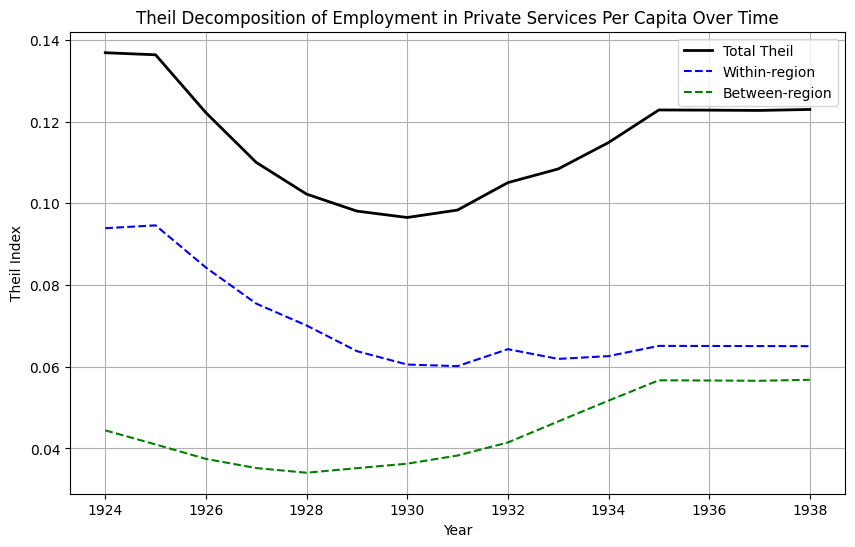

In [182]:
plot_theil_decomposition_sequence(trade_permissions_year_df, 'Total Employment Per Capita', var_title="Employment in Private Services Per Capita", save_path=plots_output_path+"/Spatial_Inequality/Services/Theil_Private_Services_Employment_per_capita", d_to_r=d_to_r, pop_by_year=production_by_year)

In [211]:
spatial_autocorrelation_over_time(trade_permissions_year_df, col_name='Total Employment Per Capita', distance_matrix=distance_matrix, threshold=120000, var_name_in_title="Employment in Private Services Per Capita", save_to_path=plots_output_path+"/Convergence_Analysis/Services/spatial_Private_Services_Employment_per_capita")

Years with 'Total Employment Per Capita': [1924, 1925, 1926, 1927, 1928, 1929, 1930, 1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938]
Plot saved to: E:/Studia/Studia magisterskie/Masterarbeit - Wirtschaftwissenschaft/post_master_data_plots/Convergence_Analysis/Services/spatial_Private_Services_Employment_per_capita


# Backup - additional examples of function use

## Harmonize an additional CSV file

In [172]:
# _, data_table_metadata_dict, _ = administrative_history.load_data_table(data_table_id = '30.06.1938-livestock_ready', version='original')

In [173]:
# input_csv_path = administrative_history.data_harmonization_input_folder + data_table_metadata_dict.data_table_id + ".csv"
# output_csv_path = administrative_history.data_harmonization_output_folder + data_table_metadata_dict.data_table_id + ".csv"
# #Harmonize single csv file
# administrative_history.harmonize_csv_file(
#                     input_csv_path=input_csv_path,
#                     output_csv_path=output_csv_path,
#                     data_table_metadata_dict=data_table_metadata_dict,
#                     date_to=reference_date
#                 )